# Dynamic IV-Surface path generation - 100 paths generation over 5 days

This notebook compares temporal generative models for **SPX implied-volatility surface paths** under a common experimental protocol.

## Experimental design

All models are trained on the same chronological training sample and evaluated against the **held-out historical test sample**. The empirical target is the collection of all rolling 5-day windows in the test set, so the comparison is distributional rather than a point forecast against one realized future path.

**Common protocol**

| Setting | Value |
|---|---:|
| IV grid | $16\times32$ |
| Generated paths | 100 |
| Forecast horizon | 5 days |
| Lag values | $L\in\{2,3,5,10\}$ |
| WMC candidate paths | 500 |
| Train/test split | Chronological |

**Lag-aware models**

- **Temporal FM** with `context_lags = L`
- **SBJTS-PCA** with `memory_order = L`
- **SBJTS-VAE** with `memory_order = L`

**Fixed references**

- **LightSB** with fixed one-step latent bridge reference
- **Cont–Vuletić** with fixed PCA + AR(1) arbitrage-aware reference

LightSB and Cont–Vuletic are generated once and reused across lag dashboards; they should **not** be interpreted as models with $L=2,3,5,$ or $10$.


## 1. Setup and data

In the following we configure the repository paths, experiment settings, reproducibility controls, and rolling 5-day historical target.


In [1]:
# imports and repo root

from pathlib import Path
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from benchmark_utils import (
    load_cube,
    orient_paths_to_tenor_money,
)

from temporal_benchmark_runner import (
    BenchmarkConfig,
    train_temporal_fm,
)

from volsurface_latentSB.sbjts_pca_vol_surface import (
    SBJTSPCAConfig,
    simulate_sbjts_pca_paths,
)

from volsurface_latentSB.sbjts_autoencoder_vol_surface import (
    SBJTSAEConfig,
    simulate_sbjts_autoencoder_paths,
)

from volsurface_latentSB.lightsb_vol_surface_github_torchcompat import (
    LightSBVolConfig,
    simulate_lightsb_paths,
)

from other_models.cont_simulations import (
    SimulationConfig,
    simulate_arbitrage_free_paths,
)

print("Repo root:", ROOT)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repo root: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation
Torch: 2.2.2
CUDA available: False


In [2]:
# settings

TRAIN_CUBE = ROOT / "data/treated/benchmark_train.npz"
TEST_CUBE  = ROOT / "data/treated/benchmark_test.npz"

OUTPUT_DIR = ROOT / "data/treated/illustration"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LAGS = [1, 2, 3, 5, 10]

N_PATHS = 100
PATH_LENGTH = 5

N_CANDIDATE_PATHS = 500
CANDIDATE_BATCH_SIZE = 128

SEED = 42
BETA_WMC = 1.0e4

# we keep the same model-size / training choices as the main temporal benchmark.
FM_LATENT_DIM = 8
FM_AE_EPOCHS = 1200
FM_EPOCHS = 1200
FM_BATCH_SIZE = 64
FM_ODE_STEPS = 64

SBJTS_VAE_LATENT_DIM = 8
SBJTS_VAE_EPOCHS = 1200

LIGHTSB_FACTORS = 8
LIGHTSB_COMPONENTS = 32
LIGHTSB_EPOCHS = 1200

# If True, a completed .npz is loaded instead of rerunning the given specification
SKIP_IF_EXISTS = True

assert TRAIN_CUBE.exists(), f"Missing {TRAIN_CUBE}"
assert TEST_CUBE.exists(), f"Missing {TEST_CUBE}"

print("Lags:", LAGS)
print("N paths:", N_PATHS)
print("Path length:", PATH_LENGTH)
print("Output:", OUTPUT_DIR)

Lags: [1, 2, 3, 5, 10]
N paths: 100
Path length: 5
Output: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration


In [3]:
# load train/test data and build the rolling 5-day target

train_cube, m_grid, tenor_days, train_dates = load_cube(TRAIN_CUBE)
test_cube, _, _, test_dates = load_cube(TEST_CUBE)

m_grid = np.asarray(m_grid, dtype=float)
tenor_days = np.asarray(tenor_days, dtype=float)

N_TENOR = len(tenor_days)
N_MONEY = len(m_grid)

# (moneyness, tenor, date) but our evaluation orientation: (date, tenor, moneyness)
REAL_TEST = np.transpose(test_cube, (2, 1, 0)).astype(np.float64)

if np.nanmedian(REAL_TEST) > 2.0:
    REAL_TEST /= 100.0

def rolling_windows(x, length):
    if x.shape[0] < length:
        raise ValueError(f"Need at least {length} held-out dates, got {x.shape[0]}")
    return np.stack(
        [x[i:i + length] for i in range(x.shape[0] - length + 1)],
        axis=0,
    )

REAL_WINDOWS = rolling_windows(REAL_TEST, PATH_LENGTH)

print("Train cube:", train_cube.shape, "dates:", len(train_dates))
print("Test cube :", test_cube.shape, "dates:", len(test_dates))
print("Real test :", REAL_TEST.shape)
print("Rolling 5-day target:", REAL_WINDOWS.shape)

assert REAL_TEST.shape[1:] == (N_TENOR, N_MONEY)
assert REAL_WINDOWS.shape[1:] == (PATH_LENGTH, N_TENOR, N_MONEY)

Train cube: (32, 16, 1400) dates: 1400
Test cube : (32, 16, 350) dates: 350
Real test : (350, 16, 32)
Rolling 5-day target: (346, 5, 16, 32)


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def to_fraction_paths(paths):
    x = np.asarray(paths, dtype=np.float64)
    x = orient_paths_to_tenor_money(x, N_TENOR, N_MONEY)

    if np.nanmedian(x) > 2.0:
        x = x / 100.0

    expected = (N_PATHS, PATH_LENGTH, N_TENOR, N_MONEY)
    if x.shape != expected:
        raise ValueError(f"Expected {expected}, got {x.shape}")

    if not np.isfinite(x).all():
        raise ValueError("Generated paths contain NaN or infinite values.")

    return x


def save_paths(path, paths, model, lag=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    kwargs = dict(
        paths=np.asarray(paths, dtype=np.float32),
        m_grid=m_grid,
        tenor_days=tenor_days,
        model=model,
    )
    if lag is not None:
        kwargs["lag"] = int(lag)

    np.savez_compressed(path, **kwargs)


def load_saved_paths(path):
    d = np.load(path, allow_pickle=True)
    return to_fraction_paths(d["paths"])


def run_or_load(path, fn, model, lag=None):
    path = Path(path)

    if SKIP_IF_EXISTS and path.exists():
        print(f"Loading existing: {path}")
        paths = load_saved_paths(path)
        return paths, 0.0, "loaded"

    t0 = time.perf_counter()
    raw = fn()
    elapsed = time.perf_counter() - t0

    if hasattr(raw, "paths"):
        raw = raw.paths

    paths = to_fraction_paths(raw)
    save_paths(path, paths, model=model, lag=lag)

    return paths, elapsed, "generated"


print("Device:", DEVICE)

Device: cpu


## 2. Lag-aware model sweep

Only the temporal-memory parameter $L$ changes across this ablation. All other model settings are held fixed so that differences across $L$ can be interpreted as sensitivity to conditioning depth.


In [5]:
# Temporal FM-trigo: train cube -> IVS autoencoder -> latent codes -> conditional FM on latent increments -> recursive latent path generation -> decode

lag_results = {}
run_log = []

for L in LAGS:
    print("\n" + "=" * 78)
    print(f"TEMPORAL FM-TRIGO — context_lags = {L}")
    print("=" * 78)

    lag_dir = OUTPUT_DIR / f"lag_{L}"
    lag_dir.mkdir(parents=True, exist_ok=True)
    out_path = lag_dir / "temporal_fm_trigo.npz"

    cfg = BenchmarkConfig(
        train_cube_path=str(TRAIN_CUBE),
        test_cube_path=str(TEST_CUBE),
        output_dir=str(lag_dir),

        n_paths=N_PATHS,
        path_length=PATH_LENGTH,
        n_candidate_paths=N_CANDIDATE_PATHS,
        candidate_batch_size=CANDIDATE_BATCH_SIZE,
        seed=SEED,
        beta_wmc=BETA_WMC,

        fm_latent_dim=FM_LATENT_DIM,
        fm_context_lags=L,
        fm_ae_epochs=FM_AE_EPOCHS,
        fm_epochs=FM_EPOCHS,
        fm_batch_size=FM_BATCH_SIZE,
        fm_ode_steps=FM_ODE_STEPS,

        sbjts_vae_latent_dim=SBJTS_VAE_LATENT_DIM,
        sbjts_vae_epochs=SBJTS_VAE_EPOCHS,

        lightsb_factors=LIGHTSB_FACTORS,
        lightsb_components=LIGHTSB_COMPONENTS,
        lightsb_epochs=LIGHTSB_EPOCHS,
    )

    try:
        paths, elapsed, status = run_or_load(
            out_path,
            lambda cfg=cfg: train_temporal_fm(cfg, DEVICE),
            model="temporal_fm_trigo",
            lag=L,
        )

        lag_results[("temporal_fm_trigo", L)] = paths

        run_log.append({
            "model": "temporal_fm_trigo",
            "lag": L,
            "status": status,
            "runtime_sec": elapsed,
        })

        print("shape:", paths.shape)
        print(f"runtime: {elapsed:.1f}s")

    except Exception as e:
        run_log.append({
            "model": "temporal_fm_trigo",
            "lag": L,
            "status": "FAILED",
            "runtime_sec": np.nan,
            "error": repr(e),
        })
        print("FAILED:", repr(e))


TEMPORAL FM-TRIGO — context_lags = 1
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_1/temporal_fm_trigo.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

TEMPORAL FM-TRIGO — context_lags = 2
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_2/temporal_fm_trigo.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

TEMPORAL FM-TRIGO — context_lags = 3
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_3/temporal_fm_trigo.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

TEMPORAL FM-TRIGO — context_lags = 5
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_5/temporal_fm_trigo.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

TEMPORAL FM-TRIGO — context_lags = 10
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/d

In [6]:
# SBJTS-PCA lag sweep

for L in LAGS:
    print("\n" + "=" * 78)
    print(f"SBJTS-PCA — memory_order = {L}")
    print("=" * 78)

    lag_dir = OUTPUT_DIR / f"lag_{L}"
    lag_dir.mkdir(parents=True, exist_ok=True)
    out_path = lag_dir / "sbjts_pca.npz"

    pca_cfg = SBJTSPCAConfig(
        input_path=TRAIN_CUBE,
        output_path=lag_dir / "_sbjts_pca_internal.npz",

        n_output_paths=N_PATHS,
        path_length=PATH_LENGTH,
        n_candidate_paths=N_CANDIDATE_PATHS,
        candidate_batch_size=CANDIDATE_BATCH_SIZE,

        # same main-benchmark representation size
        n_factors=4,
        residual_covariance="diag",

        # actual temporal memory being varied
        memory_order=L,

        bandwidth=1.0,
        min_effective_neighbors=15.0,
        jump_quantile=0.90,
        max_jump_prob=0.85,
        jump_scale=1.0,
        diffusion_scale=1.0,
        drift_scale=1.0,

        seed=SEED + 101,
        beta=BETA_WMC,
        require_zero_path=False,
        start_mode="last",
    )

    try:
        paths, elapsed, status = run_or_load(
            out_path,
            lambda cfg=pca_cfg: simulate_sbjts_pca_paths(cfg),
            model="sbjts_pca",
            lag=L,
        )

        lag_results[("sbjts_pca", L)] = paths

        run_log.append({
            "model": "sbjts_pca",
            "lag": L,
            "status": status,
            "runtime_sec": elapsed,
        })

        print("shape:", paths.shape)
        print(f"runtime: {elapsed:.1f}s")

    except Exception as e:
        run_log.append({
            "model": "sbjts_pca",
            "lag": L,
            "status": "FAILED",
            "runtime_sec": np.nan,
            "error": repr(e),
        })
        print("FAILED:", repr(e))


SBJTS-PCA — memory_order = 1
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_1/sbjts_pca.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-PCA — memory_order = 2
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_2/sbjts_pca.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-PCA — memory_order = 3
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_3/sbjts_pca.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-PCA — memory_order = 5
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_5/sbjts_pca.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-PCA — memory_order = 10
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_10/sbjts_pca.npz
shape: (100, 5, 16, 32)
ru

In [7]:
# SBJTS-VAE lag sweep

for L in LAGS:
    print("\n" + "=" * 78)
    print(f"SBJTS-VAE — memory_order = {L}")
    print("=" * 78)

    lag_dir = OUTPUT_DIR / f"lag_{L}"
    lag_dir.mkdir(parents=True, exist_ok=True)
    out_path = lag_dir / "sbjts_vae.npz"

    vae_cfg = SBJTSAEConfig(
        input_path=TRAIN_CUBE,
        output_path=lag_dir / "_sbjts_vae_internal.npz",
        autoencoder_checkpoint_path=lag_dir / "sbjts_vae.pt",

        n_output_paths=N_PATHS,
        path_length=PATH_LENGTH,
        n_candidate_paths=N_CANDIDATE_PATHS,
        candidate_batch_size=CANDIDATE_BATCH_SIZE,

        latent_dim=SBJTS_VAE_LATENT_DIM,
        ae_epochs=SBJTS_VAE_EPOCHS,
        ae_batch_size=64,

        # actual temporal memory being varied
        memory_order=L,

        residual_covariance="diag",
        bandwidth=1.0,
        min_effective_neighbors=15.0,
        jump_quantile=0.90,
        max_jump_prob=0.85,
        jump_scale=1.0,
        diffusion_scale=1.0,
        drift_scale=1.0,

        seed=SEED + 202,
        beta=BETA_WMC,
        require_zero_path=False,
        start_mode="last",

        load_autoencoder_if_exists=False,
        save_autoencoder=True,
        device=str(DEVICE),
    )

    try:
        paths, elapsed, status = run_or_load(
            out_path,
            lambda cfg=vae_cfg: simulate_sbjts_autoencoder_paths(cfg),
            model="sbjts_vae",
            lag=L,
        )

        lag_results[("sbjts_vae", L)] = paths

        run_log.append({
            "model": "sbjts_vae",
            "lag": L,
            "status": status,
            "runtime_sec": elapsed,
        })

        print("shape:", paths.shape)
        print(f"runtime: {elapsed:.1f}s")

    except Exception as e:
        run_log.append({
            "model": "sbjts_vae",
            "lag": L,
            "status": "FAILED",
            "runtime_sec": np.nan,
            "error": repr(e),
        })
        print("FAILED:", repr(e))


SBJTS-VAE — memory_order = 1
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_1/sbjts_vae.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-VAE — memory_order = 2
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_2/sbjts_vae.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-VAE — memory_order = 3
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_3/sbjts_vae.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-VAE — memory_order = 5
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_5/sbjts_vae.npz
shape: (100, 5, 16, 32)
runtime: 0.0s

SBJTS-VAE — memory_order = 10
Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/lag_10/sbjts_vae.npz
shape: (100, 5, 16, 32)
ru

In [8]:
# lag sweep status 
run_log_df = pd.DataFrame(run_log)
display(run_log_df)

expected = (N_PATHS, PATH_LENGTH, N_TENOR, N_MONEY)

print("\nSuccessful lag runs:")
for key, paths in sorted(lag_results.items()):
    print(f"{str(key):35s} {paths.shape}")
    assert paths.shape == expected, (key, paths.shape, expected)

expected_keys = {
    (model, lag)
    for model in ["temporal_fm_trigo", "sbjts_pca", "sbjts_vae"]
    for lag in LAGS
}

missing = sorted(expected_keys - set(lag_results))

if missing:
    print("\nMissing/failed specifications:")
    for key in missing:
        print(" ", key)
else:
    print("\nAll 12 lag-dependent specifications completed.")

,model,lag,status,runtime_sec
0,temporal_fm_trigo,1,loaded,0.0
1,temporal_fm_trigo,2,loaded,0.0
2,temporal_fm_trigo,3,loaded,0.0
3,temporal_fm_trigo,5,loaded,0.0
4,temporal_fm_trigo,10,loaded,0.0
5,sbjts_pca,1,loaded,0.0
6,sbjts_pca,2,loaded,0.0
7,sbjts_pca,3,loaded,0.0
8,sbjts_pca,5,loaded,0.0
9,sbjts_pca,10,loaded,0.0



Successful lag runs:
('sbjts_pca', 1)                    (100, 5, 16, 32)
('sbjts_pca', 2)                    (100, 5, 16, 32)
('sbjts_pca', 3)                    (100, 5, 16, 32)
('sbjts_pca', 5)                    (100, 5, 16, 32)
('sbjts_pca', 10)                   (100, 5, 16, 32)
('sbjts_vae', 1)                    (100, 5, 16, 32)
('sbjts_vae', 2)                    (100, 5, 16, 32)
('sbjts_vae', 3)                    (100, 5, 16, 32)
('sbjts_vae', 5)                    (100, 5, 16, 32)
('sbjts_vae', 10)                   (100, 5, 16, 32)
('temporal_fm_trigo', 1)            (100, 5, 16, 32)
('temporal_fm_trigo', 2)            (100, 5, 16, 32)
('temporal_fm_trigo', 3)            (100, 5, 16, 32)
('temporal_fm_trigo', 5)            (100, 5, 16, 32)
('temporal_fm_trigo', 10)           (100, 5, 16, 32)

All 12 lag-dependent specifications completed.


## 3. Fixed structural references

LightSB and Cont–Vuletić are generated once under the same **100-path / 5-day** protocol. Their results are repeated in the lag-specific figures solely to provide a common benchmark.


In [9]:
# LightSB 

fixed_results = {}
fixed_log = []

fixed_dir = OUTPUT_DIR / "fixed_references"
fixed_dir.mkdir(parents=True, exist_ok=True)

lightsb_path = fixed_dir / "lightsb.npz"

lightsb_cfg = LightSBVolConfig(
    input_path=TRAIN_CUBE,
    output_path=fixed_dir / "_lightsb_internal.npz",

    n_output_paths=N_PATHS,
    path_length=PATH_LENGTH,
    n_candidate_paths=N_CANDIDATE_PATHS,
    candidate_batch_size=CANDIDATE_BATCH_SIZE,

    n_factors=LIGHTSB_FACTORS,
    n_components=LIGHTSB_COMPONENTS,
    epsilon=0.12,
    epochs=LIGHTSB_EPOCHS,
    batch_size=64,

    seed=SEED + 303,
    beta=BETA_WMC,
    require_zero_path=False,
    start_mode="last",
    device=str(DEVICE),
)

try:
    paths, elapsed, status = run_or_load(
        lightsb_path,
        lambda: simulate_lightsb_paths(lightsb_cfg),
        model="lightsb",
        lag=None,
    )

    fixed_results["lightsb"] = paths
    fixed_log.append({
        "model": "lightsb",
        "structural_order": 1,
        "status": status,
        "runtime_sec": elapsed,
    })

    print("LightSB:", paths.shape, f"runtime={elapsed:.1f}s")

except Exception as e:
    fixed_log.append({
        "model": "lightsb",
        "structural_order": 1,
        "status": "FAILED",
        "runtime_sec": np.nan,
        "error": repr(e),
    })
    print("LightSB FAILED:", repr(e))

Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/fixed_references/lightsb.npz
LightSB: (100, 5, 16, 32) runtime=0.0s


In [10]:
# Cont–Vuletic PCA-AR(1)-WMC fixed reference

cont_path = fixed_dir / "cont_vuletic.npz"

cont_cfg = SimulationConfig(
    input_path=TRAIN_CUBE,
    output_path=fixed_dir / "_cont_internal.npz",

    n_output_paths=N_PATHS,
    path_length=PATH_LENGTH,
    n_candidate_paths=N_CANDIDATE_PATHS,
    candidate_batch_size=CANDIDATE_BATCH_SIZE,

    n_factors=4,

    seed=SEED + 404,
    beta=BETA_WMC,
    shock_scale=1.0,
    require_zero_path=False,
    start_mode="last",
)

try:
    paths, elapsed, status = run_or_load(
        cont_path,
        lambda: simulate_arbitrage_free_paths(cont_cfg),
        model="cont_vuletic",
        lag=None,
    )

    fixed_results["cont_vuletic"] = paths
    fixed_log.append({
        "model": "cont_vuletic",
        "structural_order": 1,
        "status": status,
        "runtime_sec": elapsed,
    })

    print("Cont–Vuletić:", paths.shape, f"runtime={elapsed:.1f}s")

except Exception as e:
    fixed_log.append({
        "model": "cont_vuletic",
        "structural_order": 1,
        "status": "FAILED",
        "runtime_sec": np.nan,
        "error": repr(e),
    })
    print("Cont–Vuletić FAILED:", repr(e))

fixed_log_df = pd.DataFrame(fixed_log)
display(fixed_log_df)

Loading existing: /Users/dusicabajalica/Desktop/M2 maths/Courses/MC/ivs_path_generation/data/treated/illustration/fixed_references/cont_vuletic.npz
Cont–Vuletić: (100, 5, 16, 32) runtime=0.0s


,model,structural_order,status,runtime_sec
0,lightsb,1,loaded,0.0
1,cont_vuletic,1,loaded,0.0


## 4. Evaluation and diagnostics

Generated paths are compared with all rolling 5-day windows from the held-out test sample. Plotting is performed in **IV percentage points** for readability.

The dashboard reports cross-sectional shape diagnostics, dynamic increment diagnostics, and static-arbitrage violation rates. Lower distance/error values indicate closer agreement with the historical sample.


### 4.1 Plotting helpers

Small helper functions identify the two closest models for each diagnostic and annotate the figures consistently.


In [11]:
# closest models 

def _top2_models(distances):
    """
    Return the first and second best models
    according to the supplied distance / error metric.

    Smaller = better.
    """

    valid = {
        k: float(v)
        for k, v in distances.items()
        if np.isfinite(v)
    }

    if len(valid) == 0:
        return []

    ranked = sorted(
        valid.items(),
        key=lambda kv: kv[1],
    )

    return ranked[:2]


def _top2_text(
    distances,
    metric_name=None,
    decimals=4,
):
    """
    Nicely formatted annotation for the two
    closest models.
    """

    top2 = _top2_models(
        distances
    )

    if len(top2) == 0:
        return "No valid model"

    lines = []

    for rank, (
        name,
        value,
    ) in enumerate(
        top2,
        start=1,
    ):

        if metric_name is None:

            lines.append(
                f"{rank}. {DISPLAY[name]}: "
                f"{value:.{decimals}f}"
            )

        else:

            lines.append(
                f"{rank}. {DISPLAY[name]}: "
                f"{metric_name}={value:.{decimals}f}"
            )

    return "\n".join(
        lines
    )


def _add_closest_note(
    ax,
    text,
):

    ax.text(
        0.02,
        0.97,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.7",
            alpha=0.90,
        ),
    )

### 4.2 Main diagnostic dashboard

For each lag $L$, the notebook produces:

1. a diagnostic dashboard covering term structure, smile shape, increments, step magnitude, marginal $W_2$ diagnostics, and static arbitrage;
2. mean implied-volatility surfaces;
3. absolute mean-surface error plots.

The wing-spread quantities shown in the distributional diagnostics are **smile-shape proxies**, not mathematical butterfly-convexity tests. Static butterfly arbitrage is assessed separately through convexity of normalized Black call prices.


Selected grid points:
80%   = 0.8000
90%   = 0.9032
ATM   = 0.9935
110%  = 1.0968
120%  = 1.2000
Smile maturity = 58 days


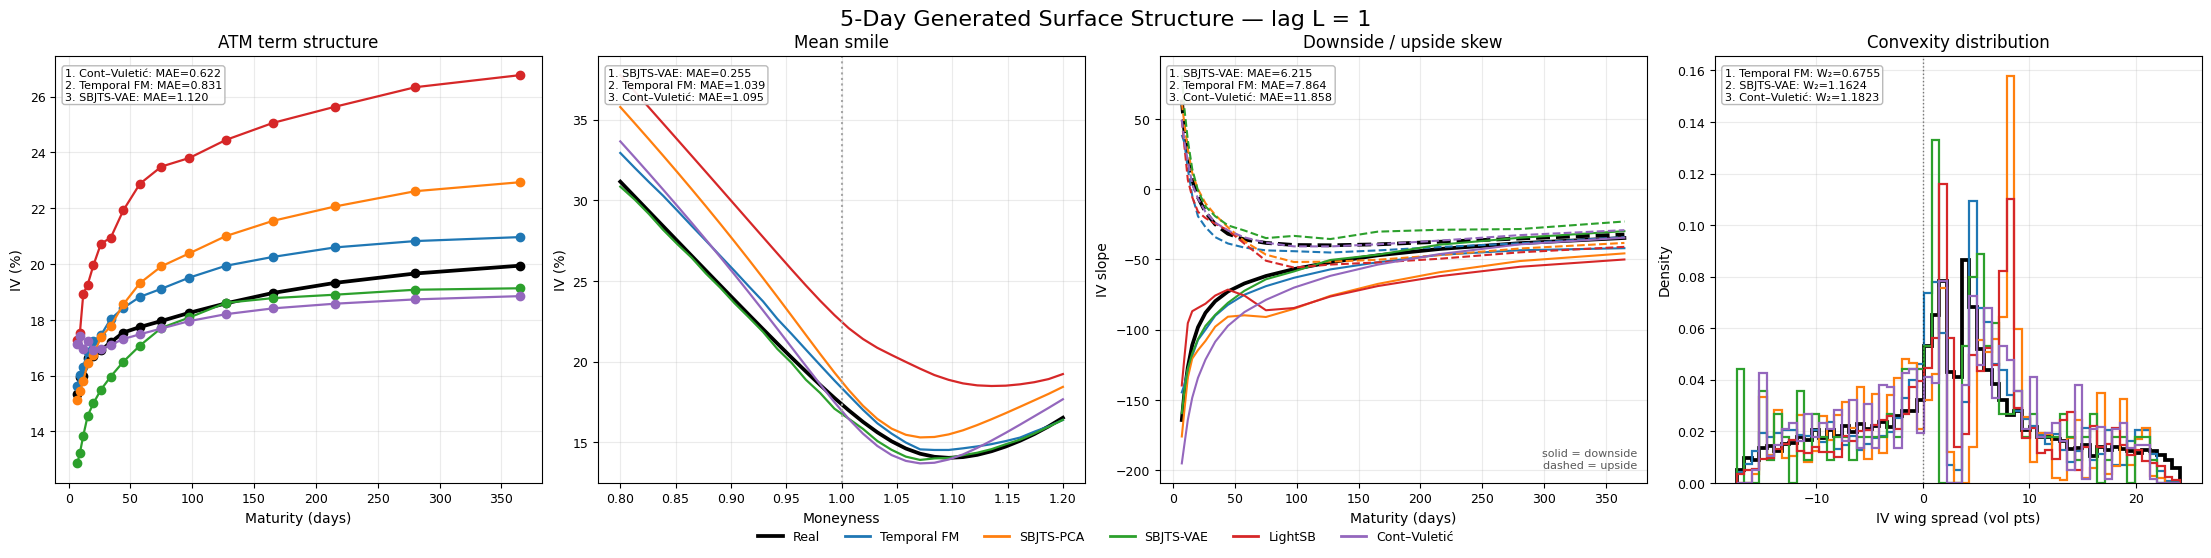

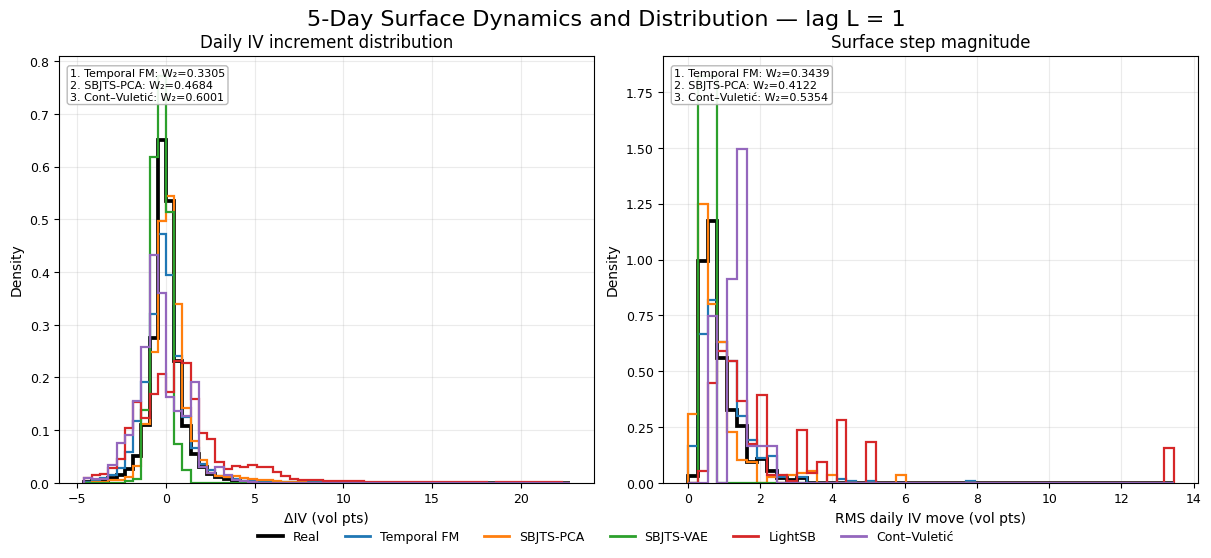

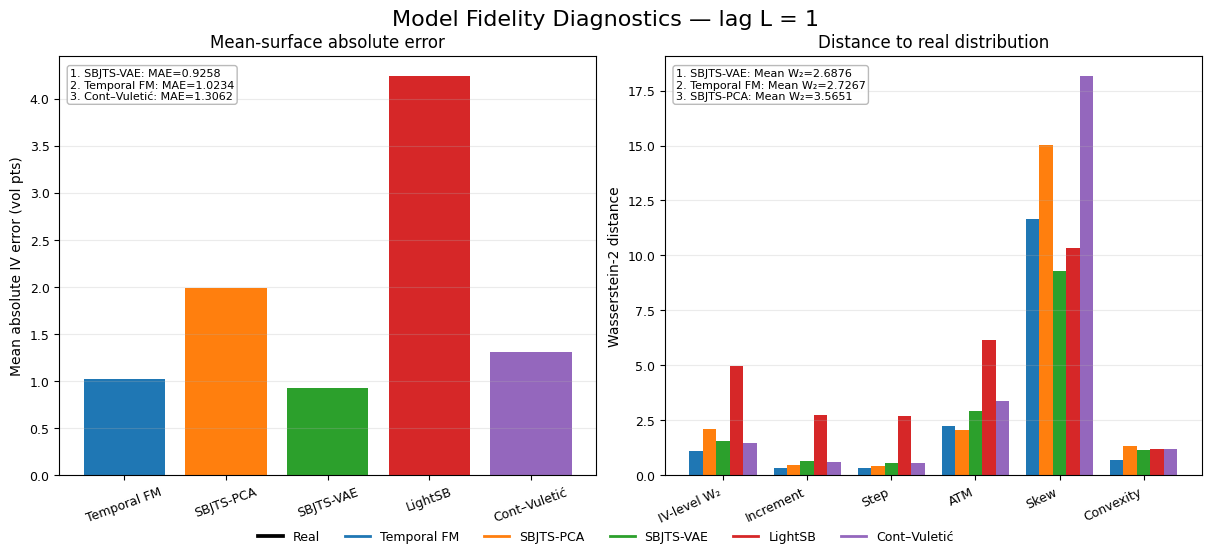

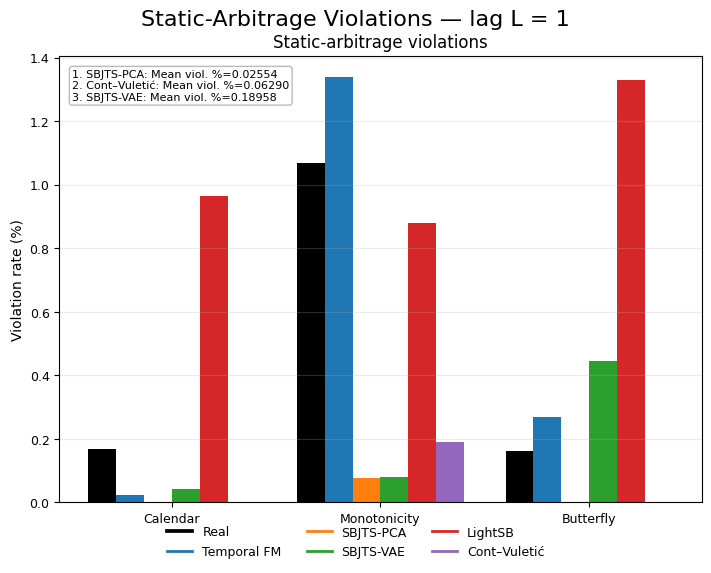

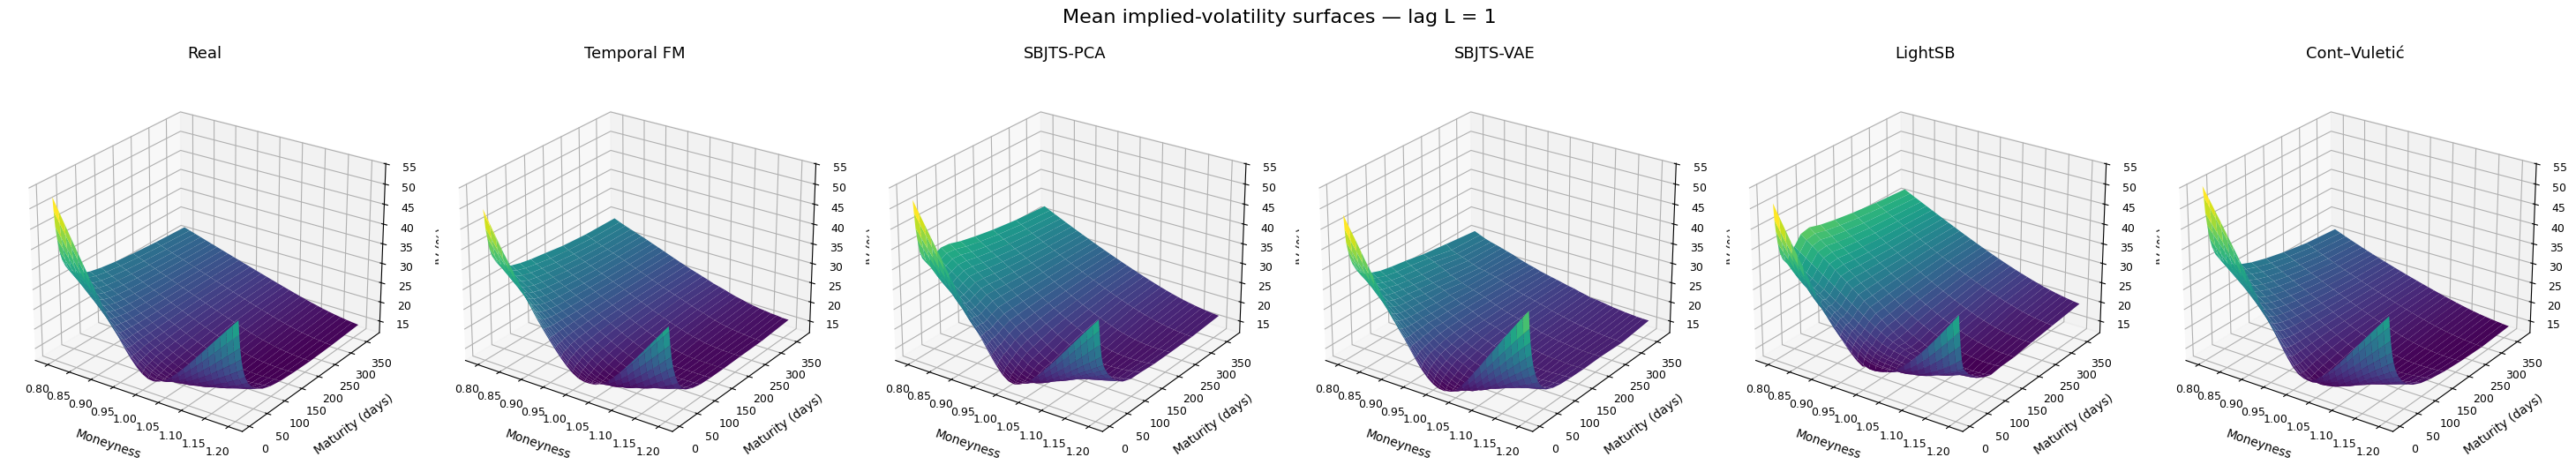

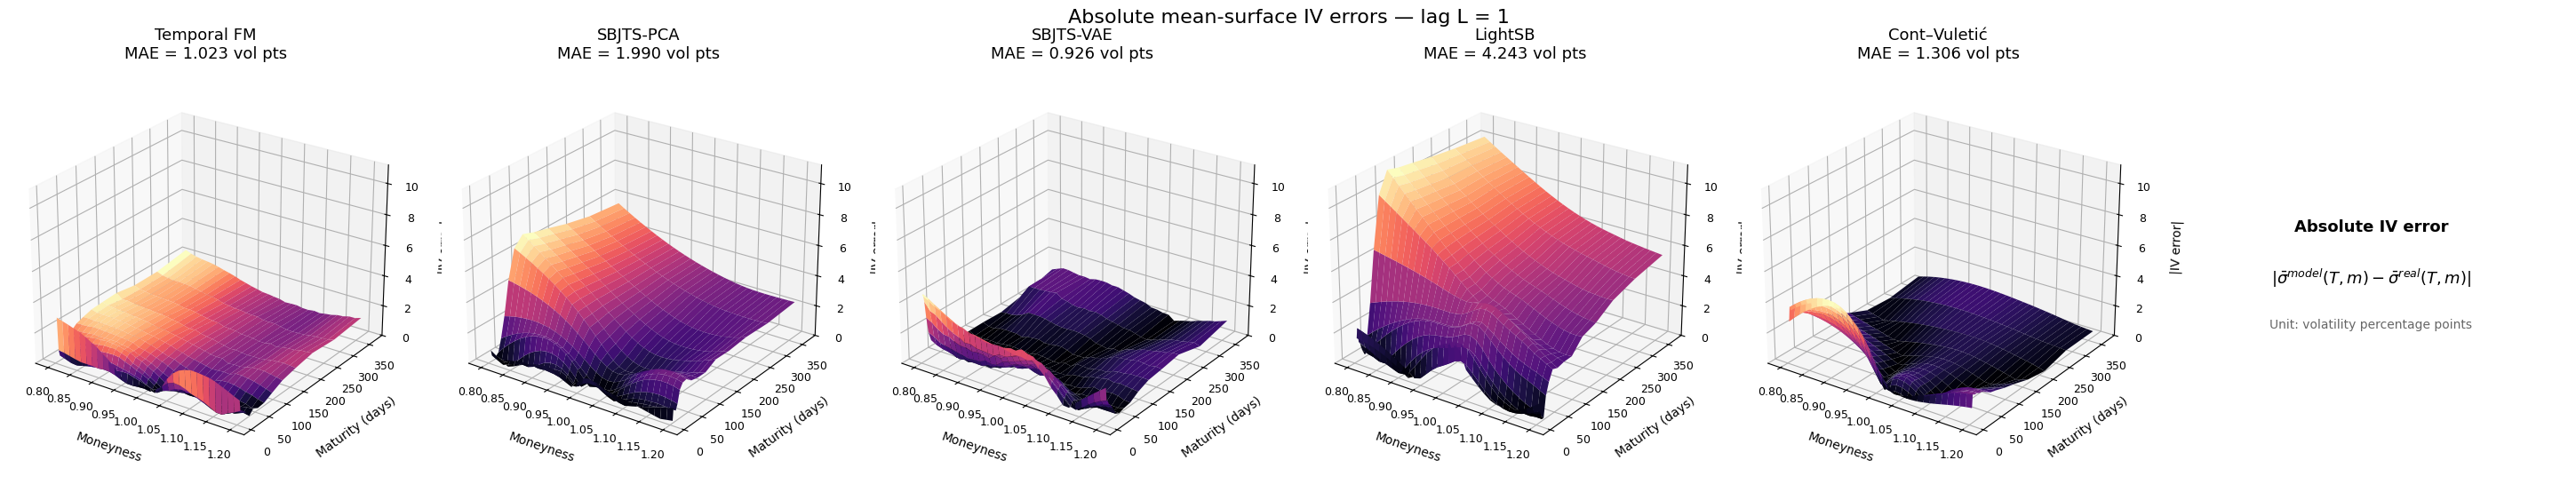

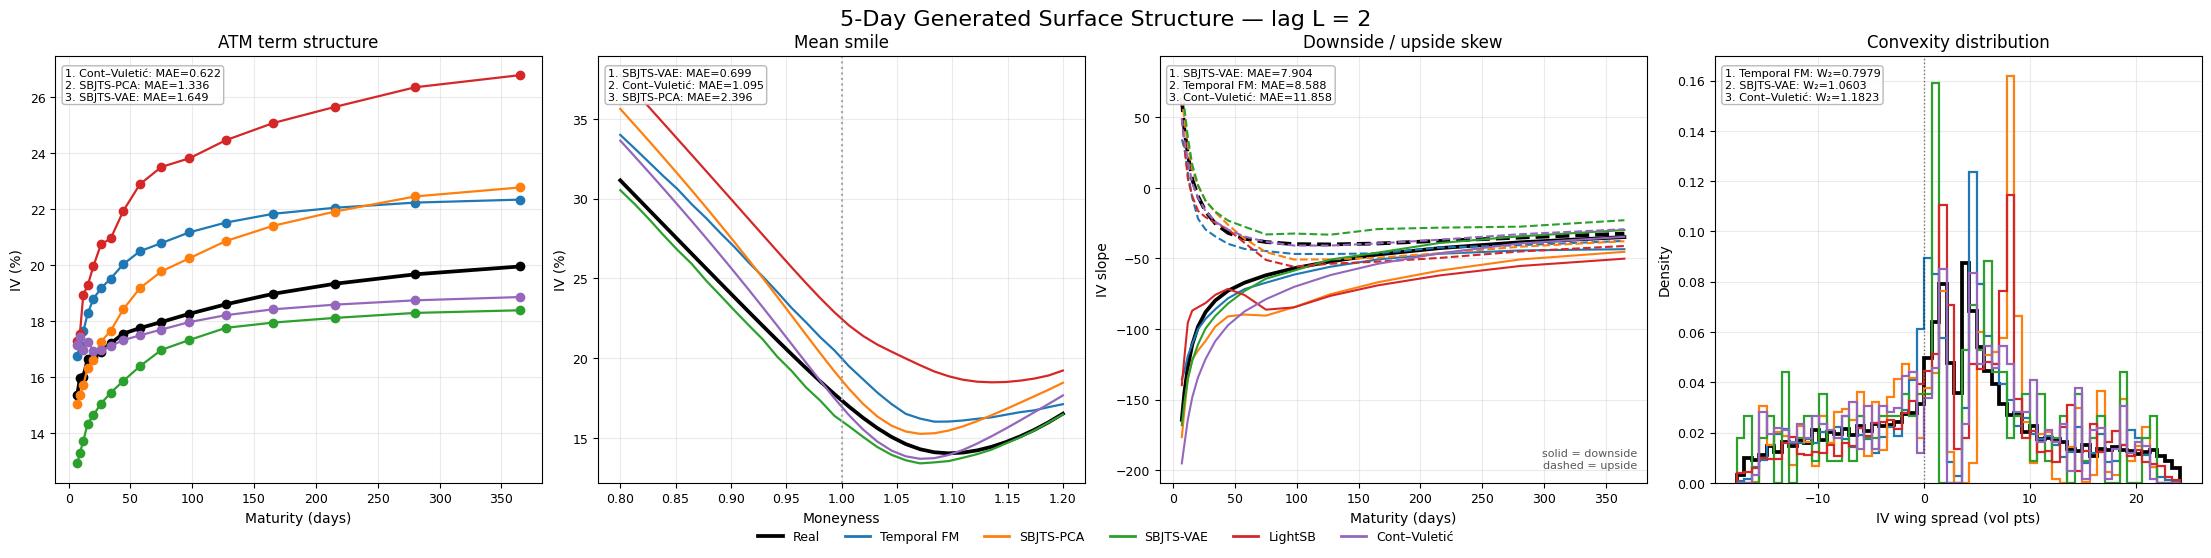

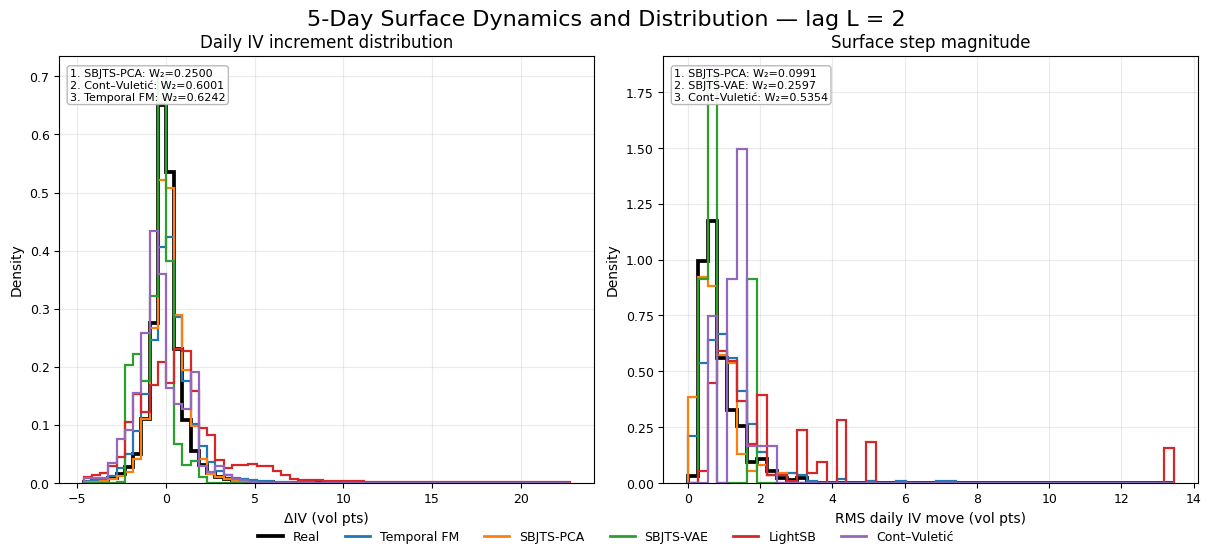

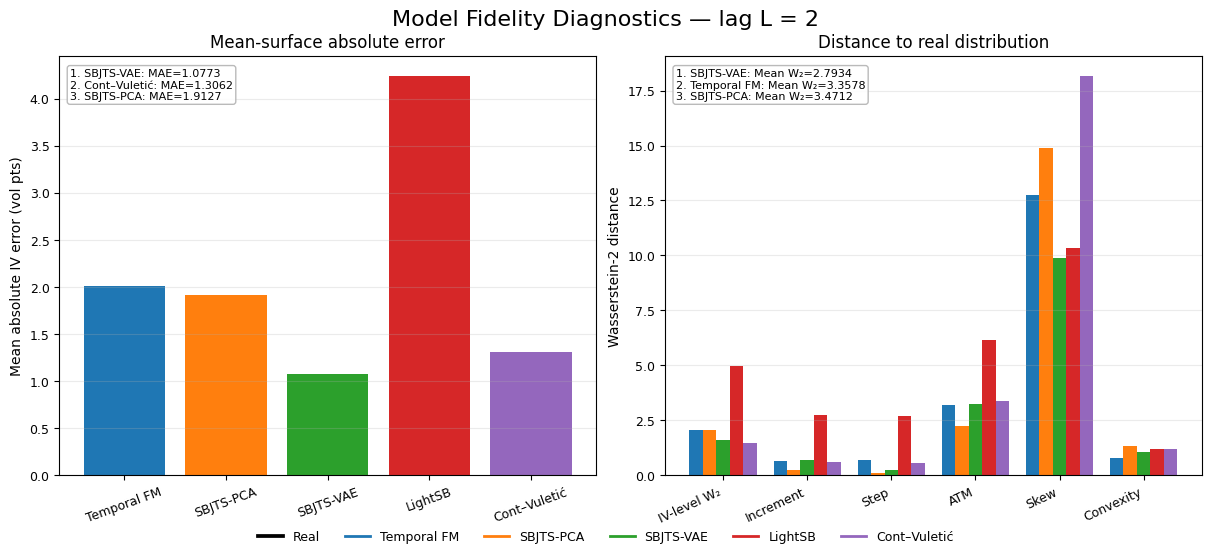

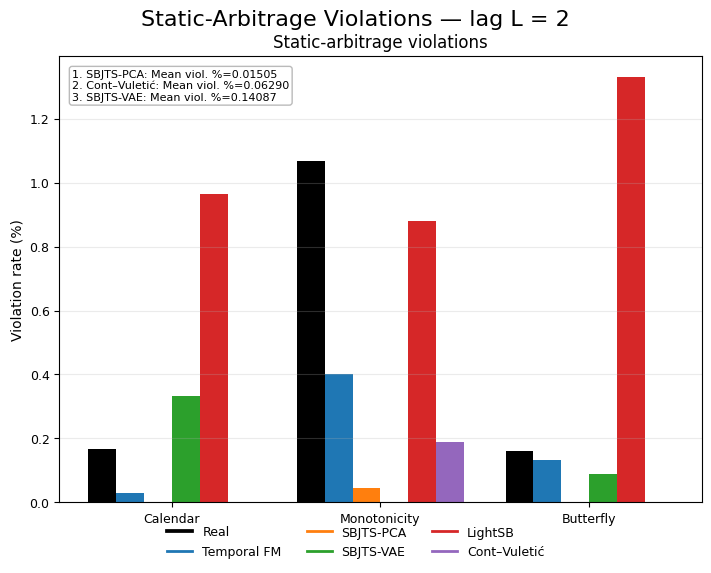

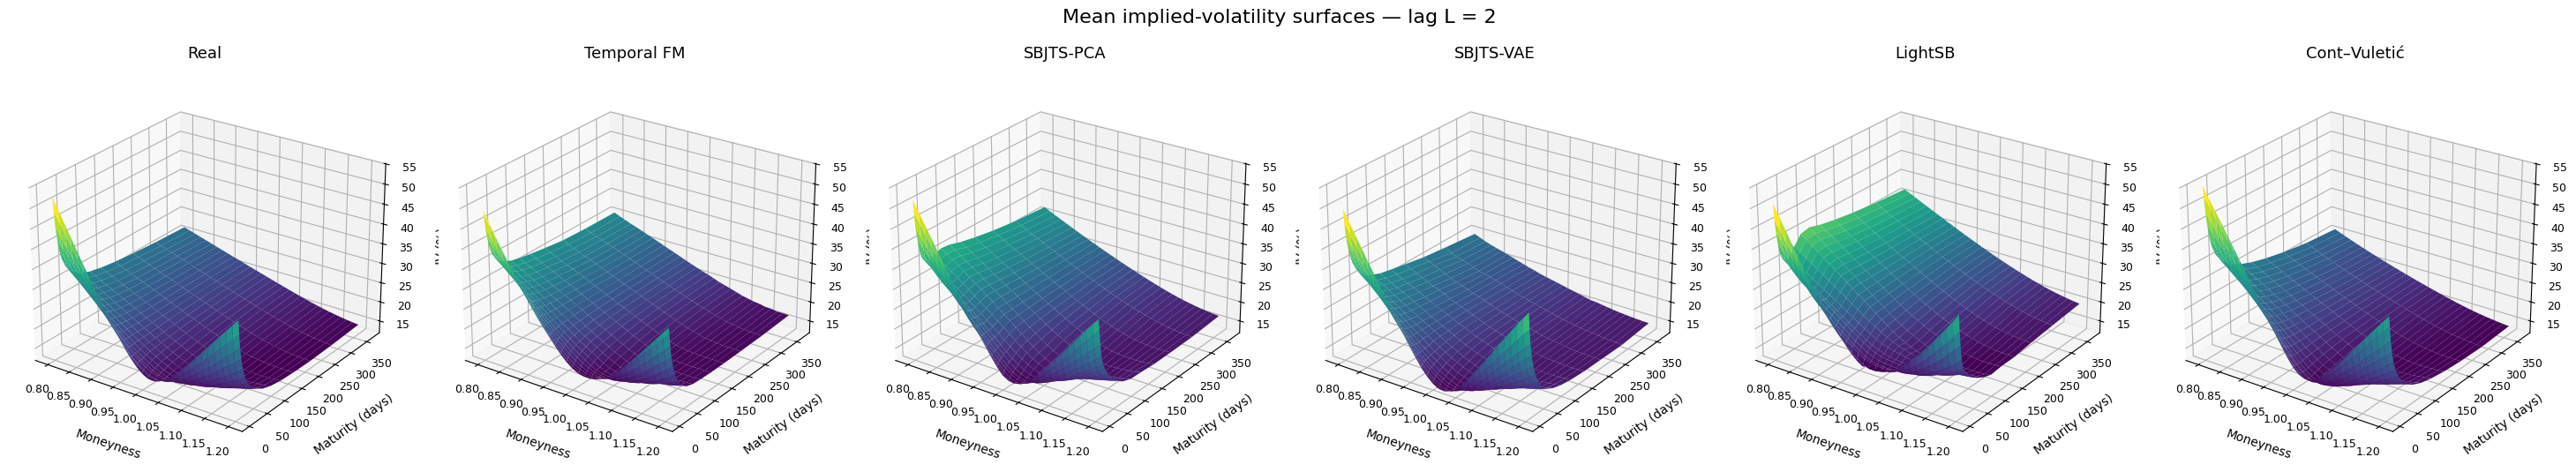

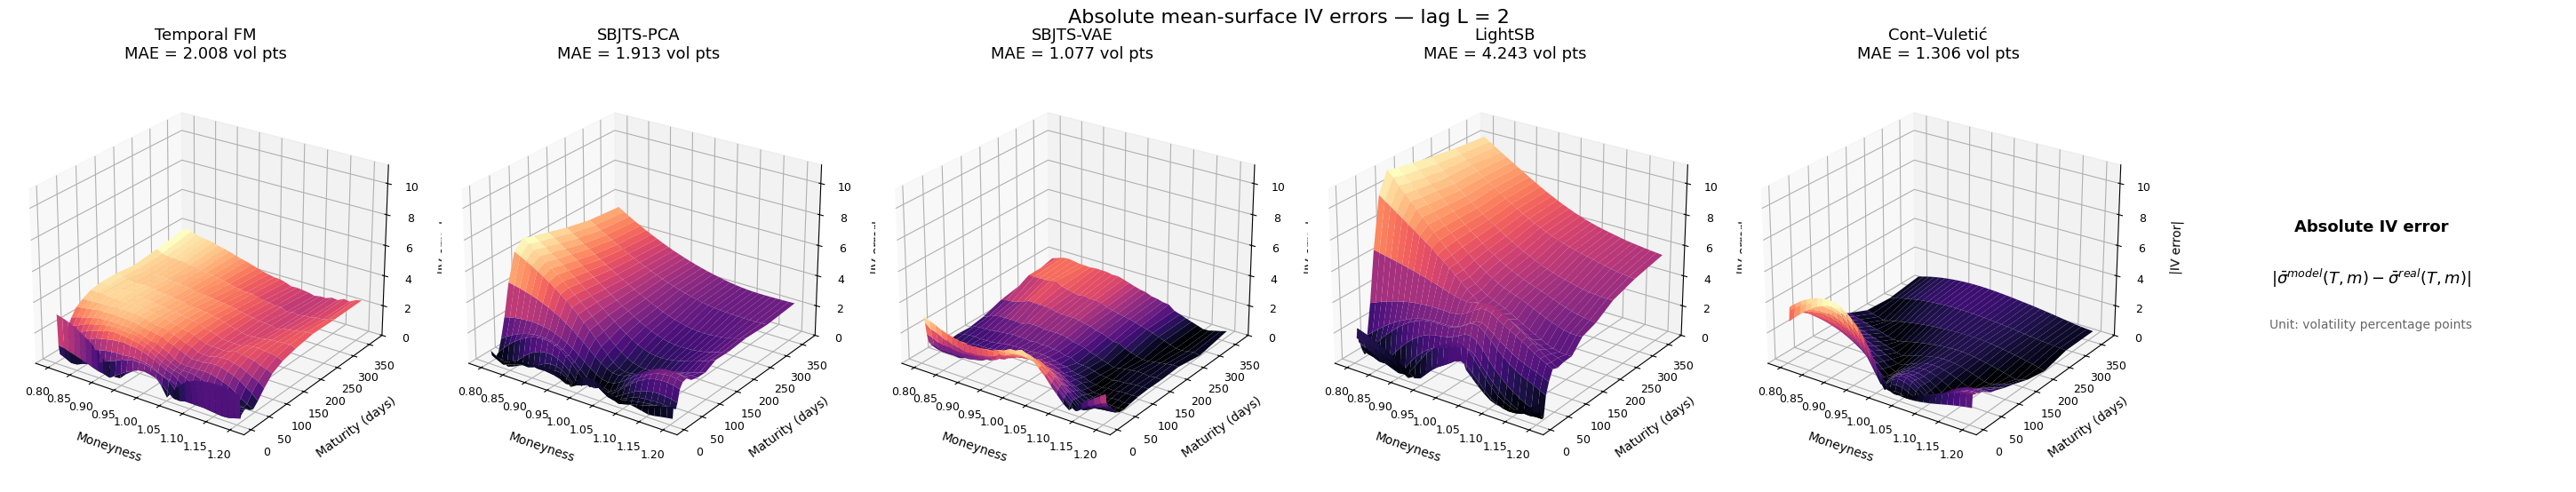

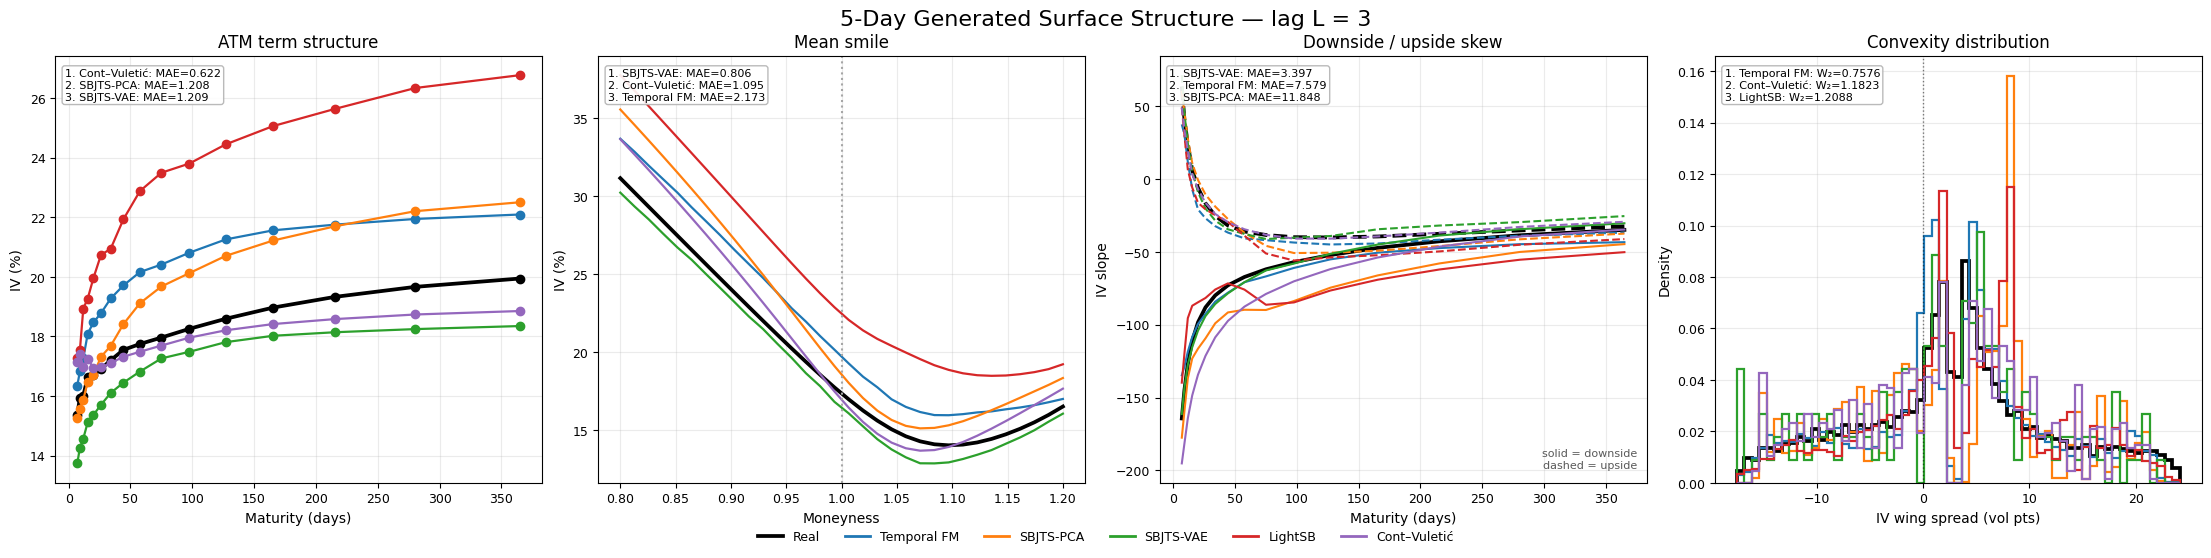

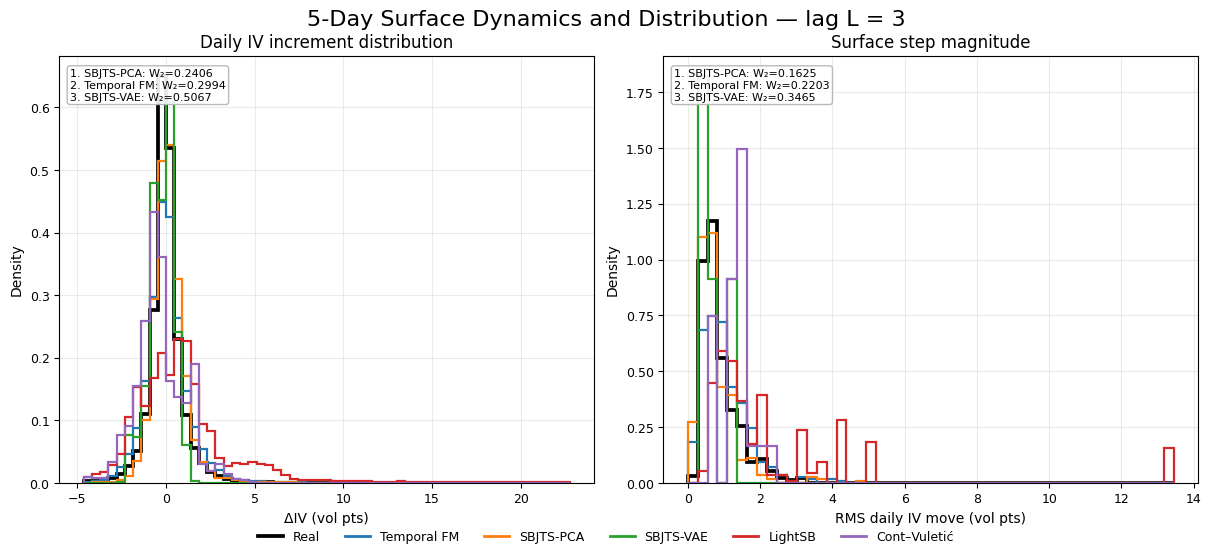

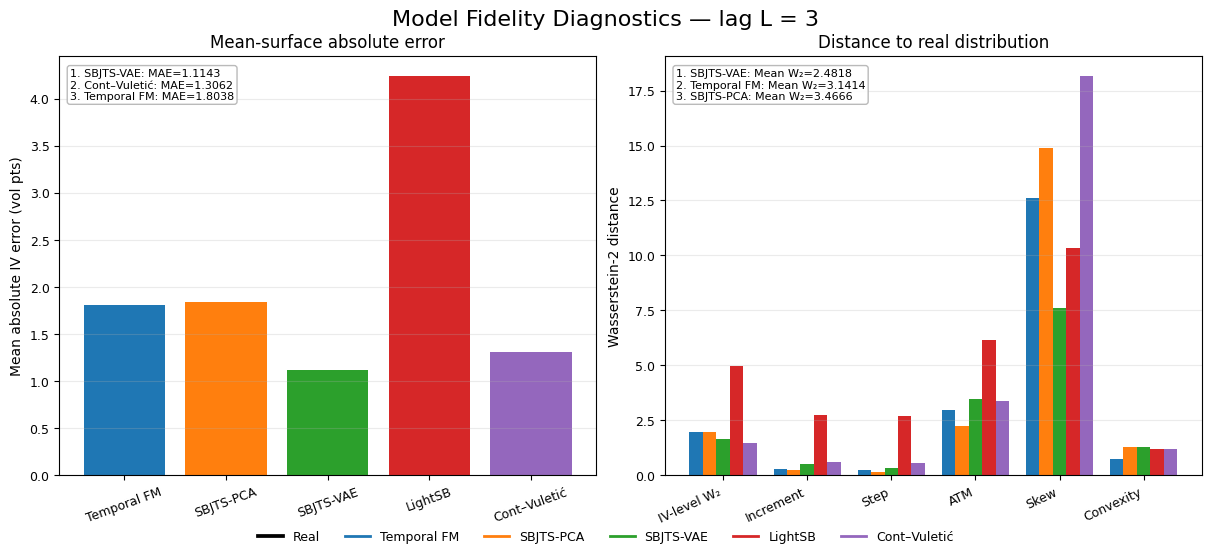

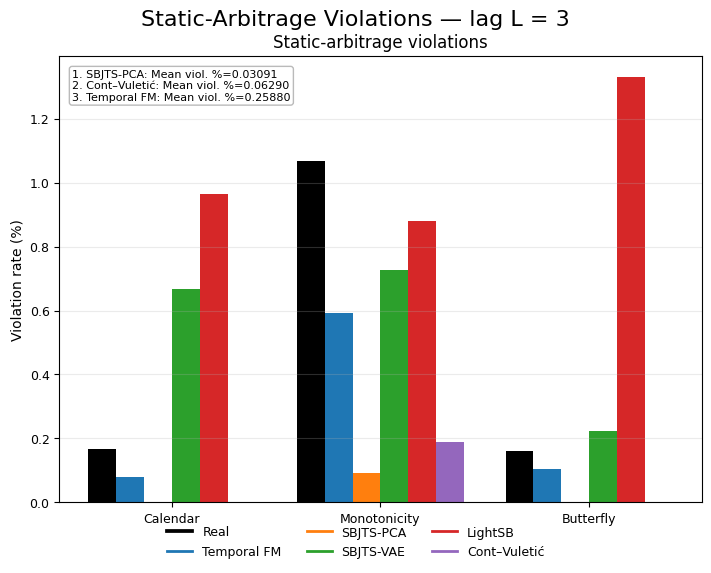

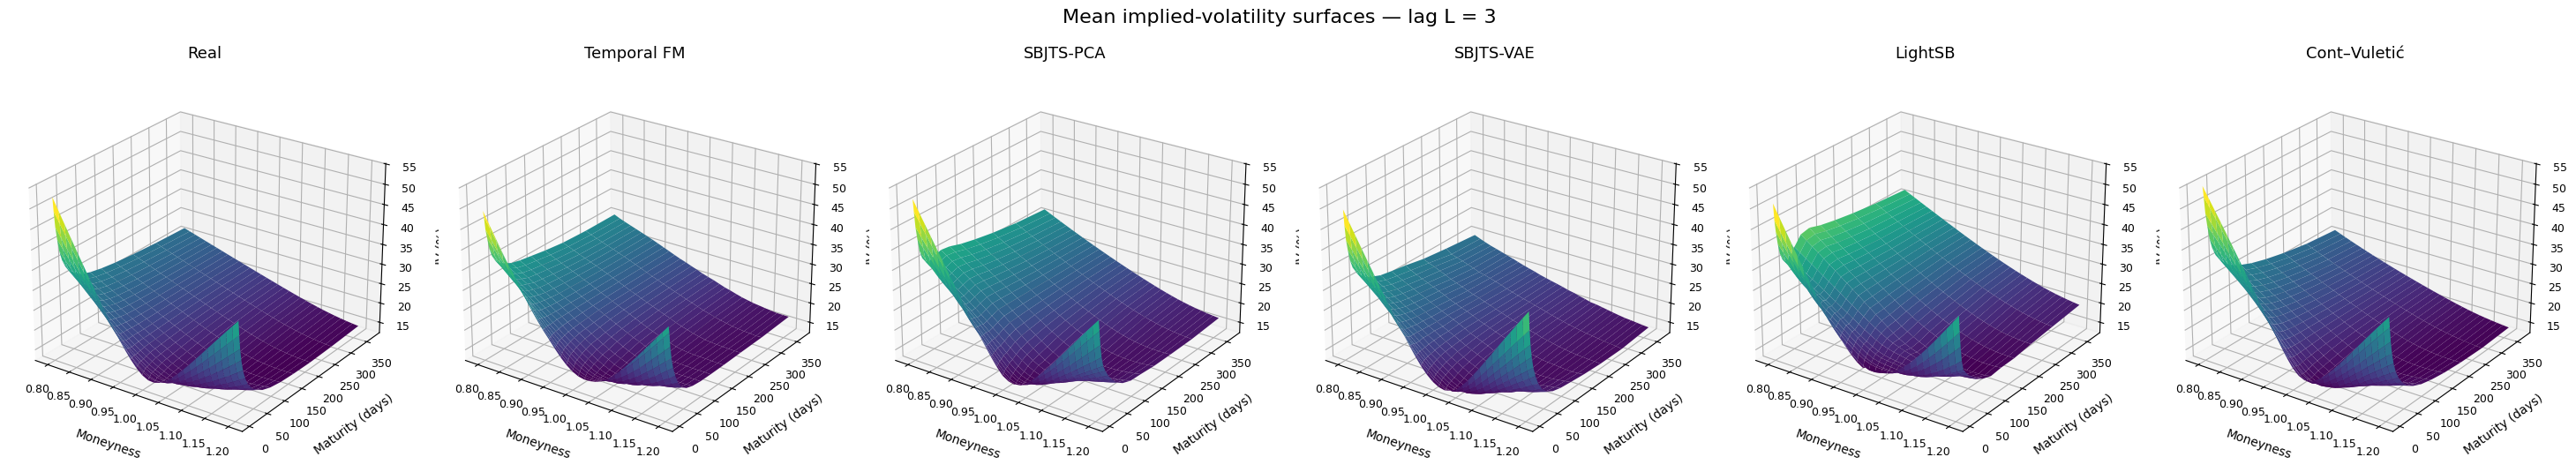

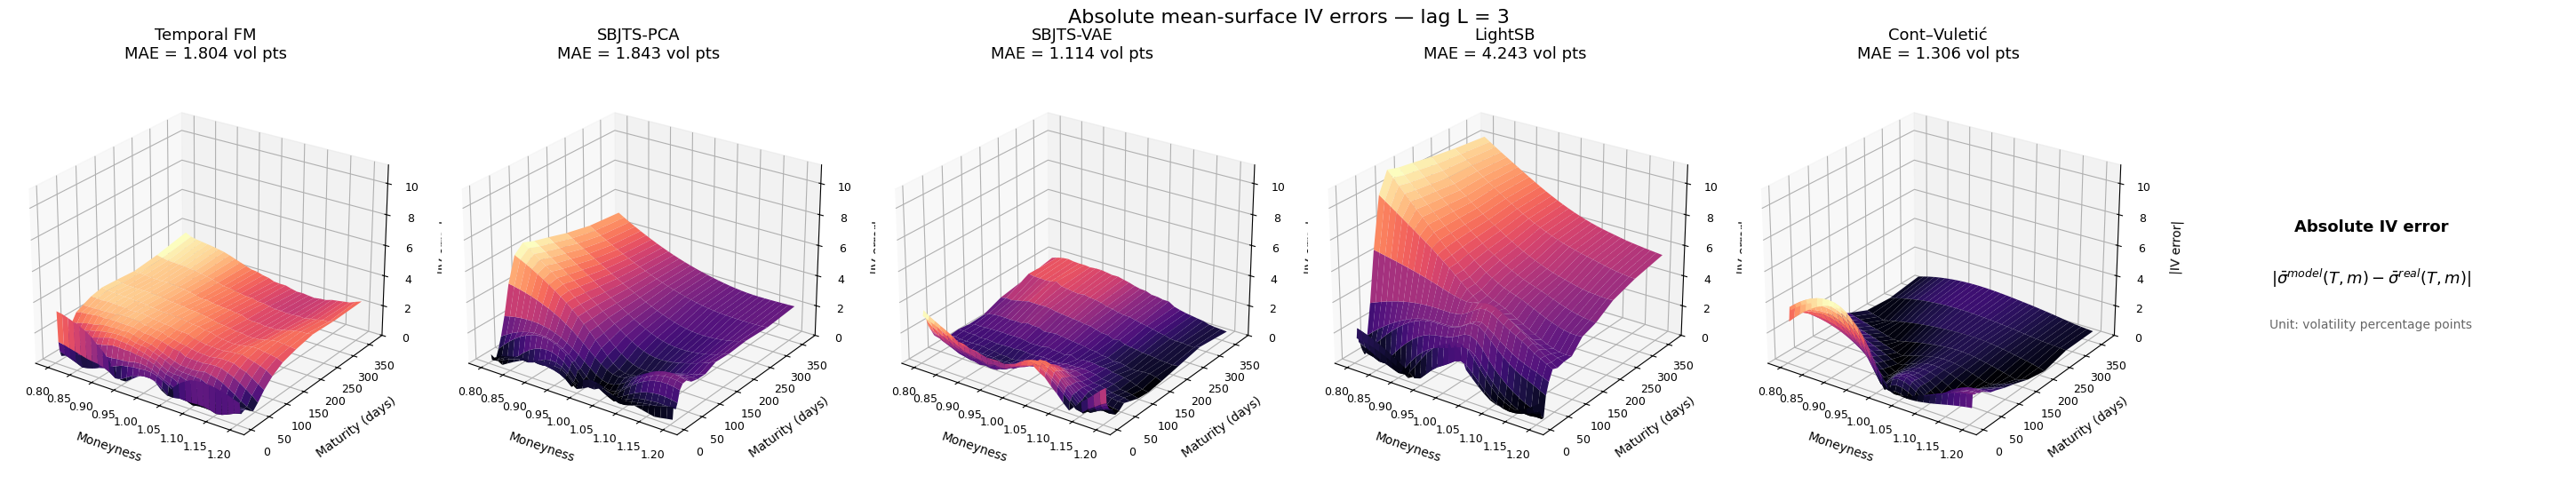

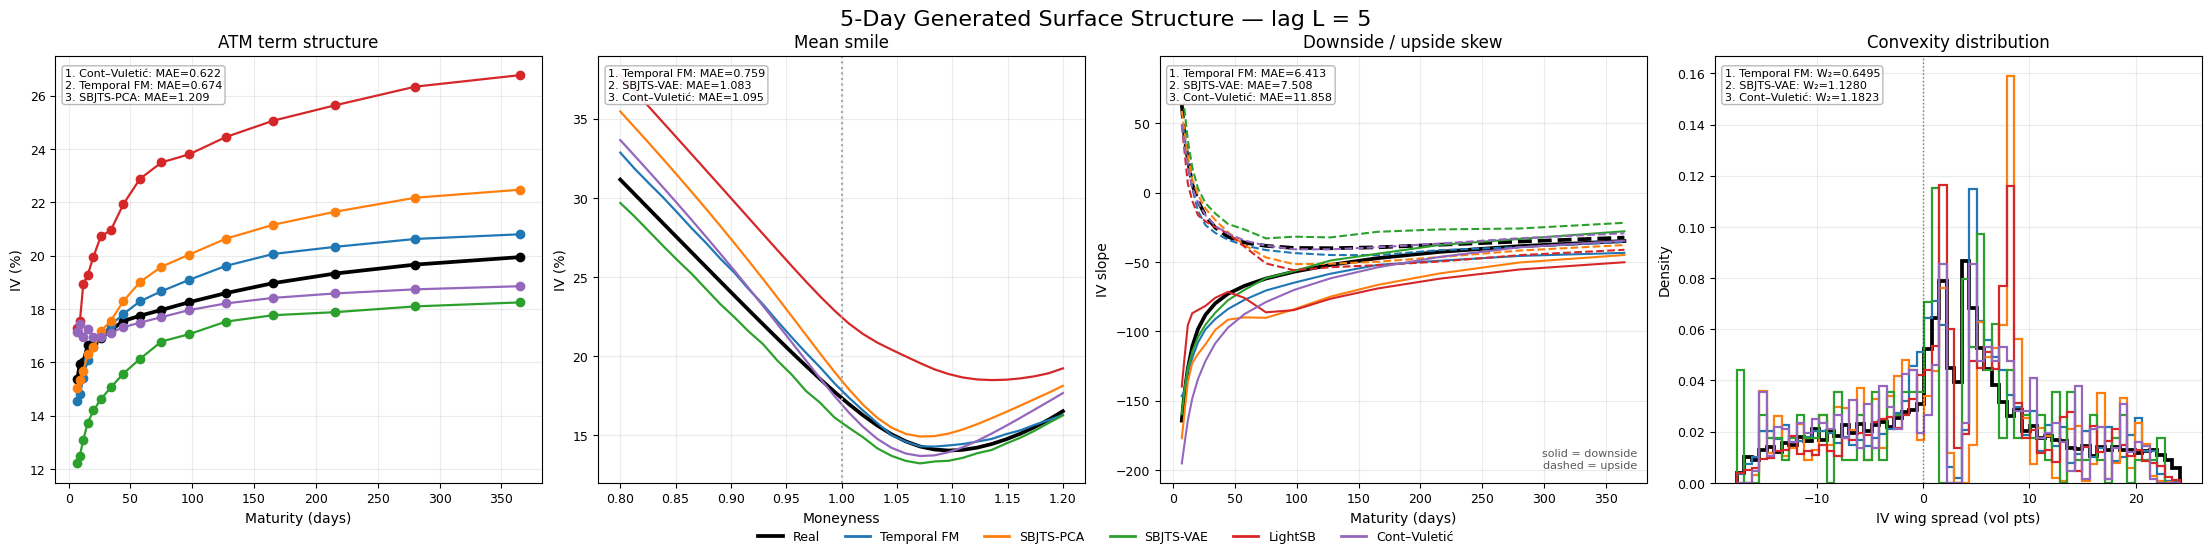

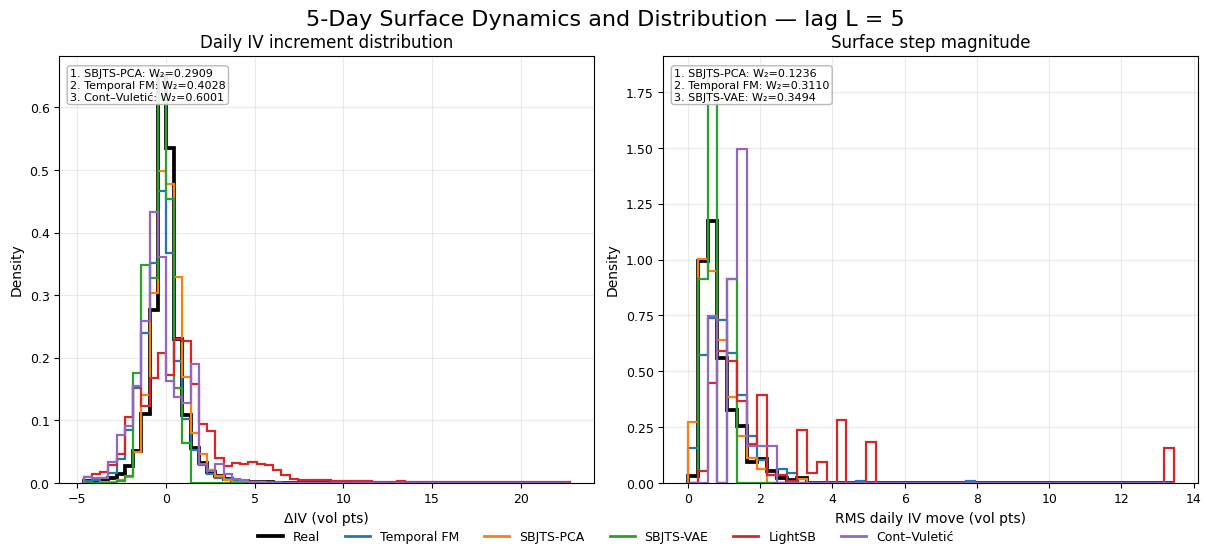

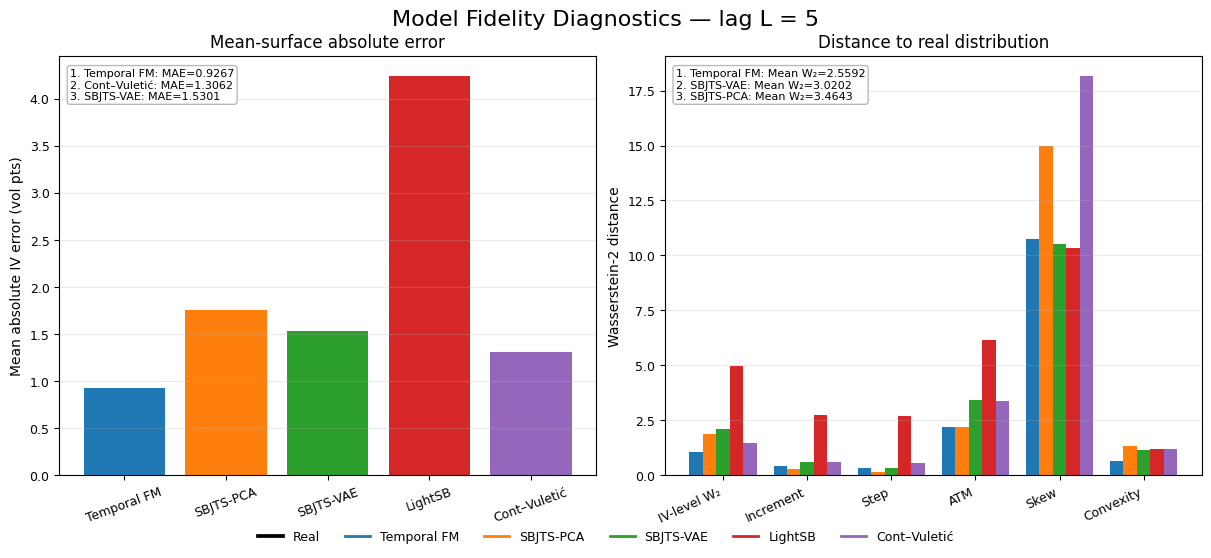

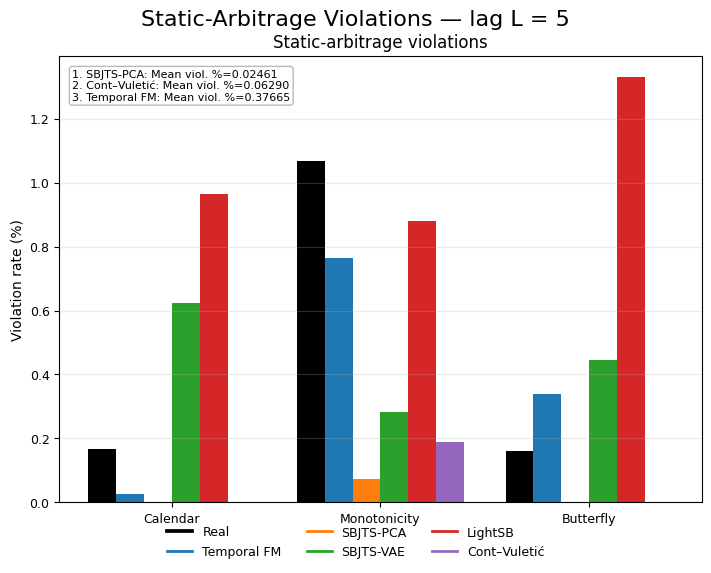

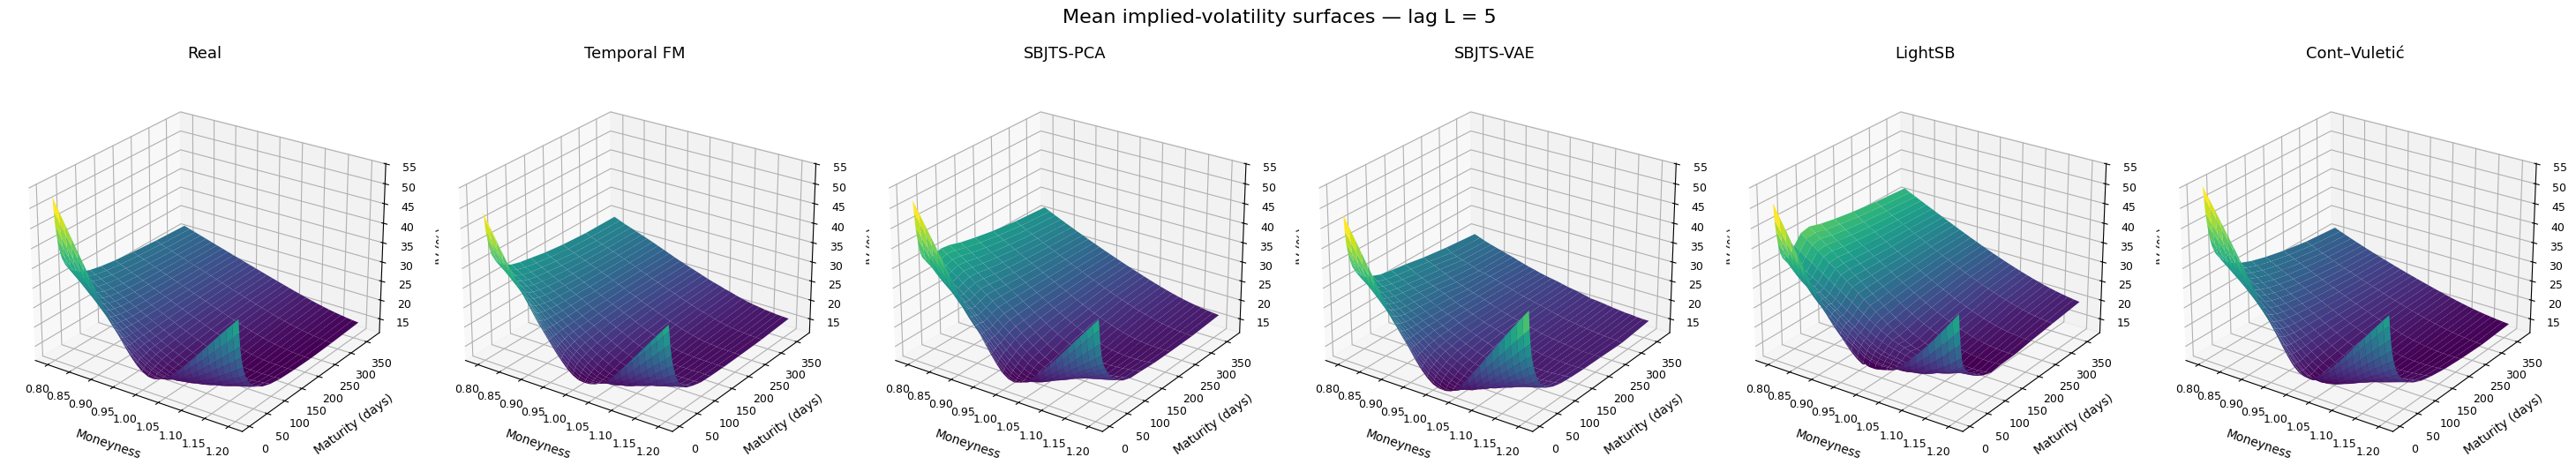

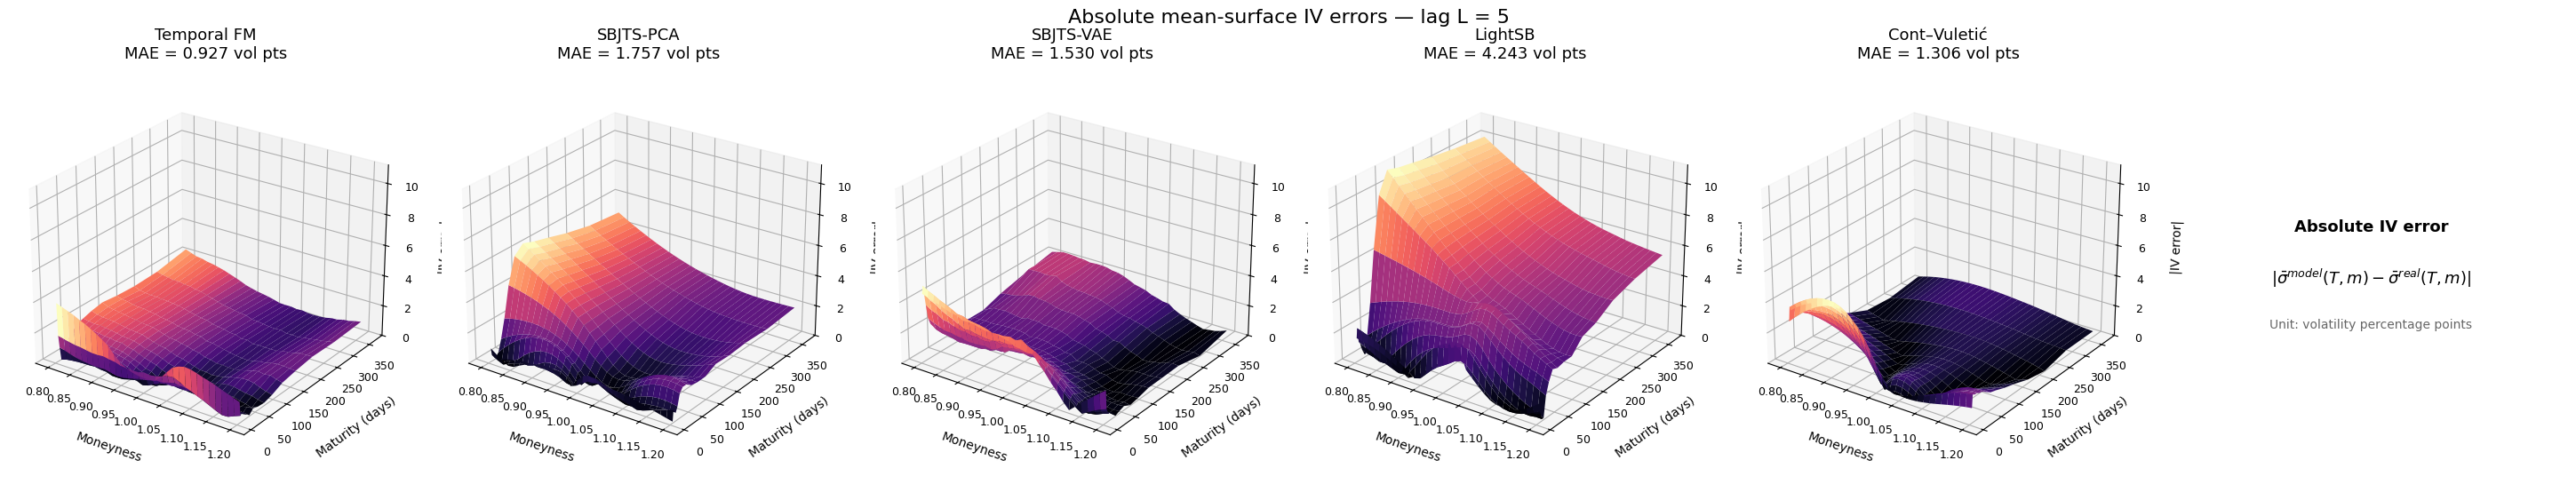

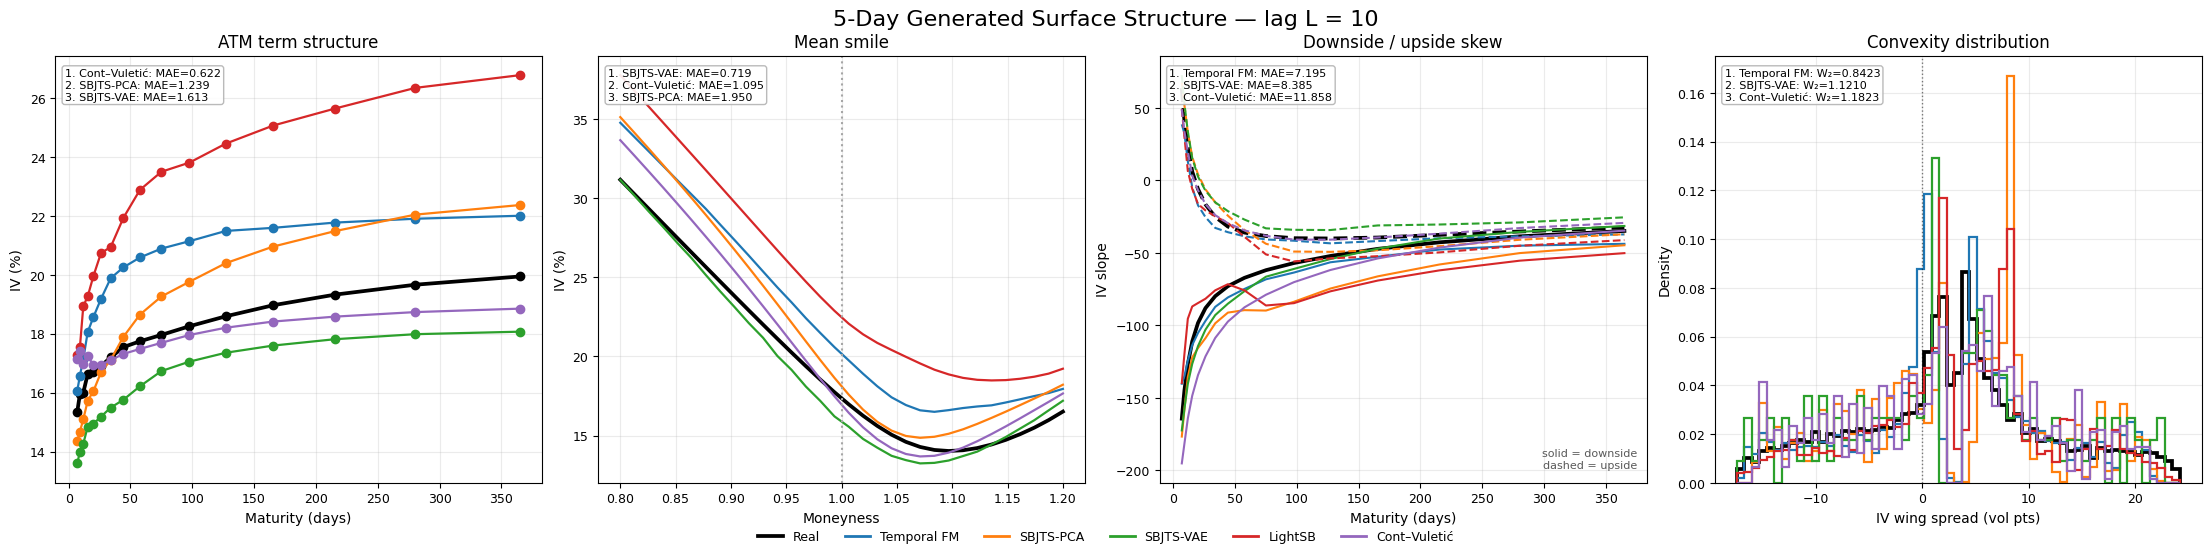

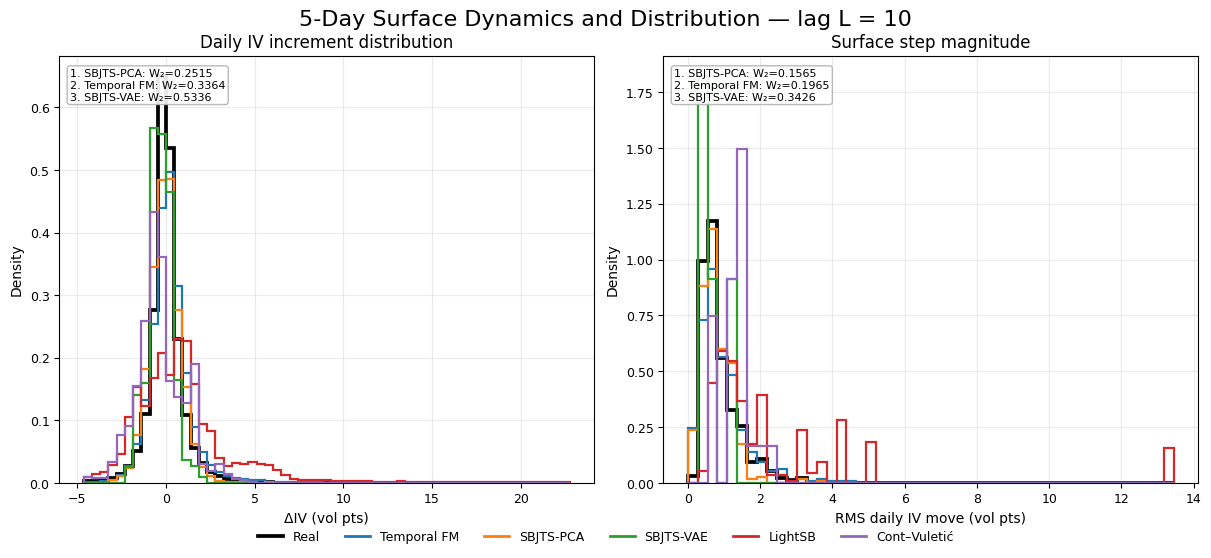

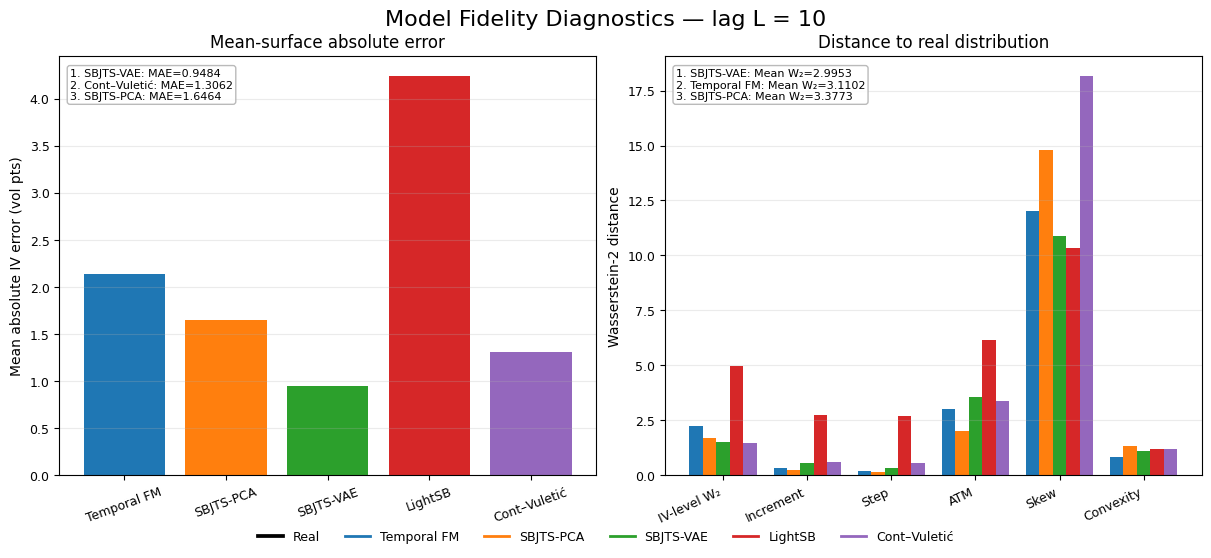

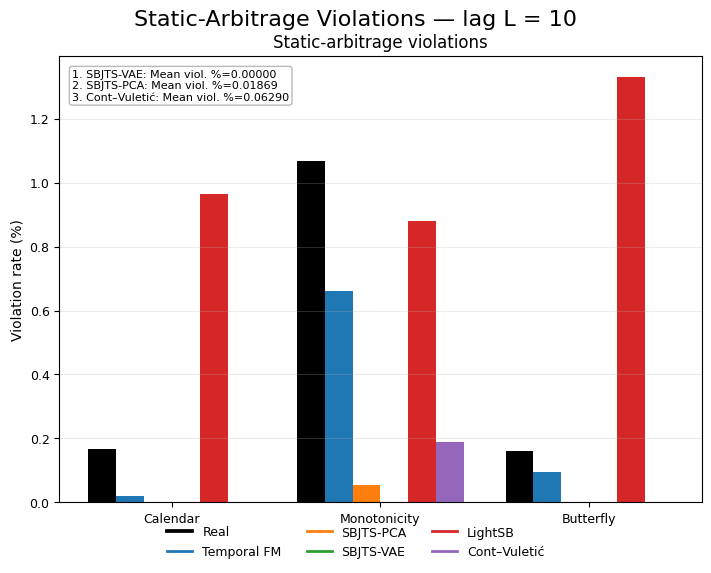

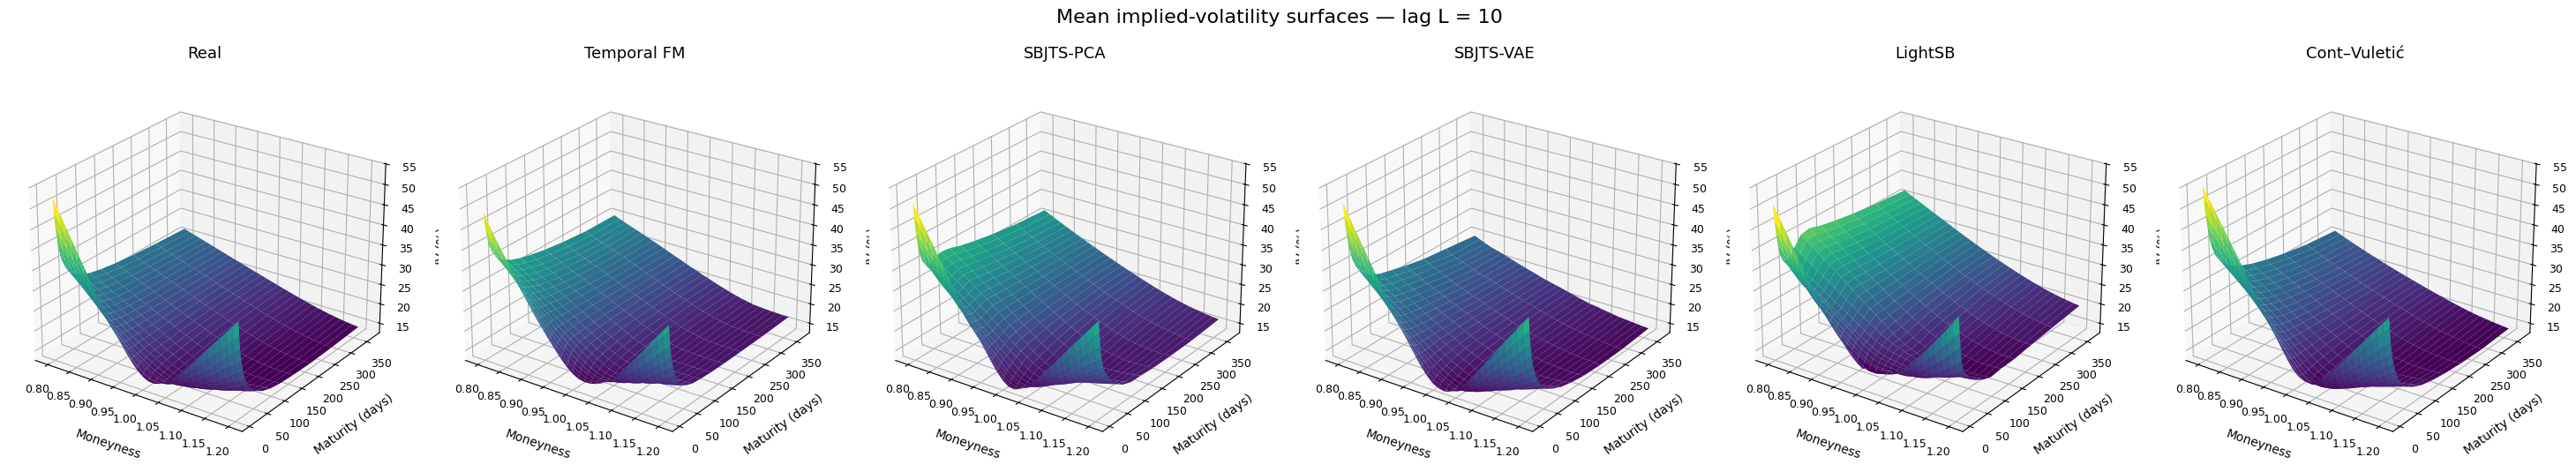

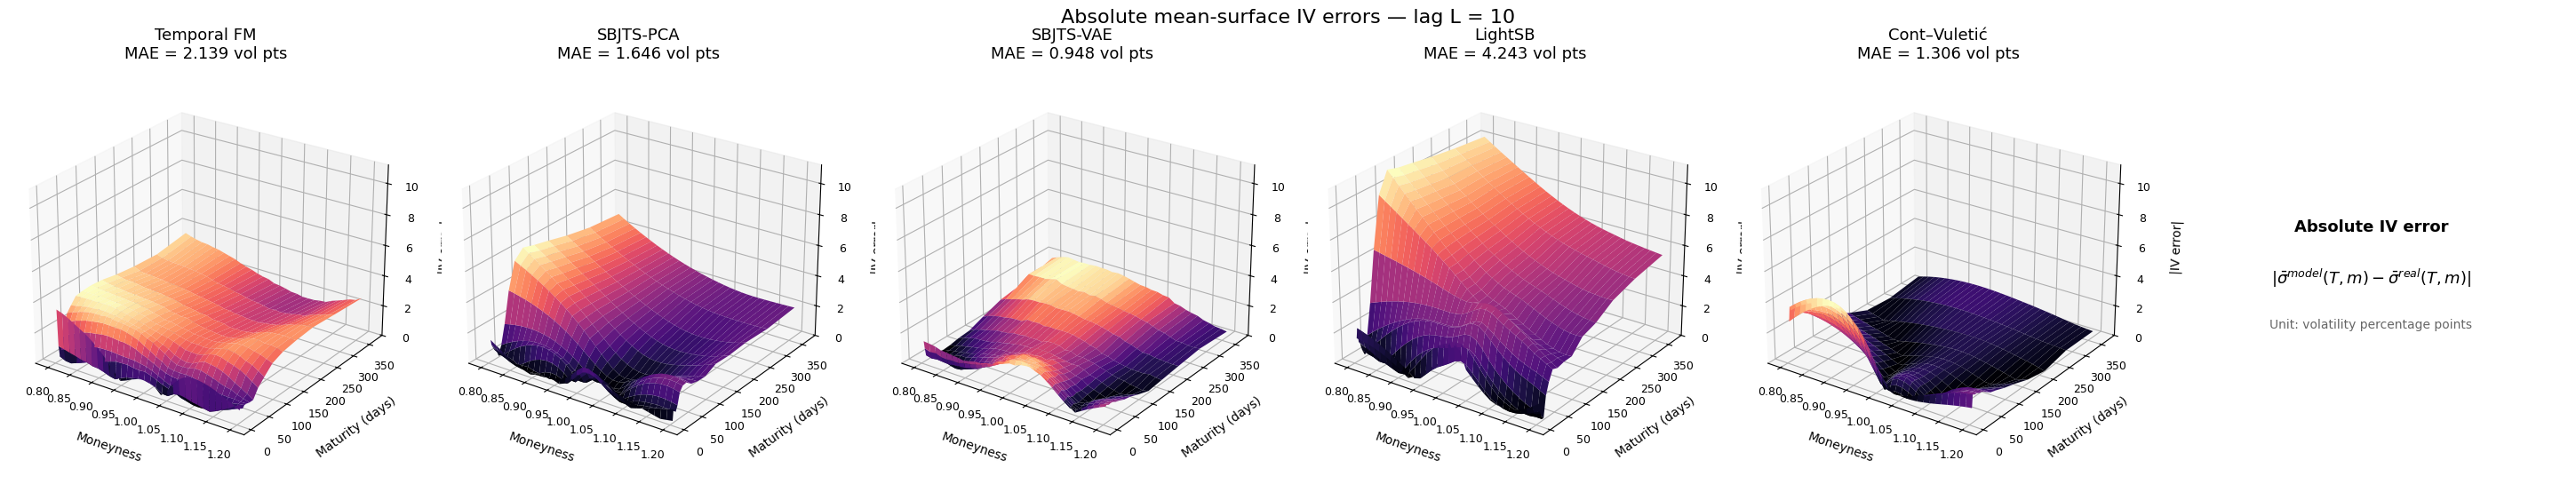

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

import matplotlib as mpl



mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "figure.titlesize": 14,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# config

LAG_MODELS = [
    "temporal_fm_trigo",
    "sbjts_pca",
    "sbjts_vae",
]

FIXED_MODELS = [
    "lightsb",
    "cont_vuletic",
]

MODEL_ORDER = [
    "temporal_fm_trigo",
    "sbjts_pca",
    "sbjts_vae",
    "lightsb",
    "cont_vuletic",
]

DISPLAY = {
    "temporal_fm_trigo": "Temporal FM",
    "sbjts_pca": "SBJTS-PCA",
    "sbjts_vae": "SBJTS-VAE",
    "lightsb": "LightSB",
    "cont_vuletic": "Cont–Vuletić",
}

COLORS = {
    "real": "black",
    "temporal_fm_trigo": "tab:blue",
    "sbjts_pca": "tab:orange",
    "sbjts_vae": "tab:green",
    "lightsb": "tab:red",
    "cont_vuletic": "tab:purple",
}


m_grid = np.asarray(
    m_grid,
    dtype=float,
)

tenor_days = np.asarray(
    tenor_days,
    dtype=float,
)

IDX_80 = int(
    np.argmin(
        np.abs(m_grid - 0.80)
    )
)

IDX_90 = int(
    np.argmin(
        np.abs(m_grid - 0.90)
    )
)

IDX_ATM = int(
    np.argmin(
        np.abs(m_grid - 1.00)
    )
)

IDX_110 = int(
    np.argmin(
        np.abs(m_grid - 1.10)
    )
)

IDX_120 = int(
    np.argmin(
        np.abs(m_grid - 1.20)
    )
)

MID_T = len(tenor_days) // 2


print("Selected grid points:")
print(f"80%   = {m_grid[IDX_80]:.4f}")
print(f"90%   = {m_grid[IDX_90]:.4f}")
print(f"ATM   = {m_grid[IDX_ATM]:.4f}")
print(f"110%  = {m_grid[IDX_110]:.4f}")
print(f"120%  = {m_grid[IDX_120]:.4f}")
print(
    f"Smile maturity = "
    f"{tenor_days[MID_T]:.0f} days"
)


def _pct(x):

    x = np.asarray(
        x,
        dtype=float,
    ).copy()

    if np.nanmedian(x) < 2:
        x *= 100.0

    return x


REAL_PLOT = _pct(
    REAL_WINDOWS
)


def _flat(x):

    x = np.asarray(
        x,
        dtype=float,
    ).reshape(-1)

    return x[
        np.isfinite(x)
    ]


def _mean_surface(x):

    return np.nanmean(
        x,
        axis=(0, 1),
    )


def _increments(x):

    return np.diff(
        x,
        axis=1,
    )


def _step_l2(x):
    """
    RMS full-surface move between consecutive dates.
    """

    dx = _increments(x)

    return np.sqrt(
        np.mean(
            dx**2,
            axis=(-2, -1),
        )
    )




def _w2(a, b):

    a = np.sort(
        _flat(a)
    )

    b = np.sort(
        _flat(b)
    )

    if len(a) == 0 or len(b) == 0:
        return np.nan

    na = len(a)
    nb = len(b)

    wa = 1.0 / na
    wb = 1.0 / nb

    i = 0
    j = 0

    rem_a = wa
    rem_b = wb

    dist2 = 0.0

    eps = 1e-15

    while i < na and j < nb:

        mass = min(
            rem_a,
            rem_b,
        )

        dist2 += (
            mass
            * (a[i] - b[j])**2
        )

        rem_a -= mass
        rem_b -= mass

        if rem_a <= eps:
            i += 1
            rem_a = wa

        if rem_b <= eps:
            j += 1
            rem_b = wb

    return float(
        np.sqrt(dist2)
    )


def _atm(x):

    return x[
        ...,
        IDX_ATM,
    ]


def _downside_skew(x):
    """
    Same convention as previous benchmark.
    """

    return (
        x[..., IDX_90]
        - x[..., IDX_ATM]
    ) / (
        m_grid[IDX_90]
        - m_grid[IDX_ATM]
    )


def _upside_skew(x):

    return (
        x[..., IDX_ATM]
        - x[..., IDX_110]
    ) / (
        m_grid[IDX_ATM]
        - m_grid[IDX_110]
    )


def _downside_convexity(x):
    """
    Desk-style downside wing-spread proxy.
    NOT mathematical call-price convexity.
    """

    return (
        x[..., IDX_80]
        - x[..., IDX_90]
    )


def _upside_convexity(x):
    """
    Desk-style upside wing-spread proxy.
    NOT mathematical call-price convexity.
    """

    return (
        x[..., IDX_110]
        - x[..., IDX_120]
    )


# closest models

def _top2_models(distances):
    """
    Rank models from smallest metric to largest metric.
    """

    valid = {
        k: float(v)
        for k, v in distances.items()
        if np.isfinite(v)
    }

    if len(valid) == 0:
        return []

    ranked = sorted(
        valid.items(),
        key=lambda kv: kv[1],
    )

    return ranked[:3]


def _top2_text(
    distances,
    metric_name=None,
    decimals=4,
):

    top2 = _top2_models(
        distances
    )

    if len(top2) == 0:
        return "No valid model"

    lines = []

    for rank, (
        name,
        value,
    ) in enumerate(
        top2,
        start=1,
    ):

        if metric_name is None:

            text = (
                f"{rank}. {DISPLAY[name]}: "
                f"{value:.{decimals}f}"
            )

        else:

            text = (
                f"{rank}. {DISPLAY[name]}: "
                f"{metric_name}={value:.{decimals}f}"
            )

        lines.append(
            text
        )

    return "\n".join(
        lines
    )


def _add_closest_note(
    ax,
    text,
):

    ax.text(
        0.02,
        0.97,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.7",
            alpha=0.90,
        ),
    )



def _normalised_call(iv_pct):

    sigma = (
        np.asarray(
            iv_pct,
            dtype=float,
        )
        / 100.0
    )

    sigma = np.maximum(
        sigma,
        1e-8,
    )

    tau = (
        tenor_days
        / 365.0
    )

    tau_b = tau.reshape(
        (1,) * (sigma.ndim - 2)
        + (len(tau), 1)
    )

    m_b = m_grid.reshape(
        (1,) * (sigma.ndim - 1)
        + (len(m_grid),)
    )

    vol_sqrt_t = (
        sigma
        * np.sqrt(tau_b)
    )

    d1 = (
        -np.log(m_b)
        + 0.5
        * sigma**2
        * tau_b
    ) / vol_sqrt_t

    d2 = (
        d1
        - vol_sqrt_t
    )

    return (
        norm.cdf(d1)
        - m_b * norm.cdf(d2)
    )


def _arbitrage_rates(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    # Calendar
    tau = (
        tenor_days
        / 365.0
    )

    tau_b = tau.reshape(
        (1,) * (x.ndim - 2)
        + (len(tau), 1)
    )

    iv = (
        x
        / 100.0
    )

    total_var = (
        iv**2
        * tau_b
    )

    calendar_viol = (
        np.diff(
            total_var,
            axis=-2,
        )
        < -1e-10
    )

    calendar_rate = (
        100.0
        * np.mean(
            calendar_viol
        )
    )

    # Call monotonicity
    calls = _normalised_call(
        x
    )

    monotonicity_viol = (
        np.diff(
            calls,
            axis=-1,
        )
        > 1e-10
    )

    monotonicity_rate = (
        100.0
        * np.mean(
            monotonicity_viol
        )
    )

    # Butterfly
    dc_dm = np.gradient(
        calls,
        m_grid,
        axis=-1,
        edge_order=2,
    )

    d2c = np.gradient(
        dc_dm,
        m_grid,
        axis=-1,
        edge_order=2,
    )

    d2c_inner = (
        d2c[
            ...,
            2:-2
        ]
    )

    butterfly_viol = (
        d2c_inner
        < -1e-8
    )

    butterfly_rate = (
        100.0
        * np.mean(
            butterfly_viol
        )
    )

    return (
        calendar_rate,
        monotonicity_rate,
        butterfly_rate,
    )



for L in LAGS:

    models = {}

    for model in LAG_MODELS:

        key = (
            model,
            L,
        )

        if key in lag_results:

            models[model] = _pct(
                lag_results[key]
            )

    for model in FIXED_MODELS:

        if model in fixed_results:

            models[model] = _pct(
                fixed_results[model]
            )

    if len(models) == 0:

        print(
            f"No models available for L={L}"
        )

        continue

    ordered_models = [
        name
        for name in MODEL_ORDER
        if name in models
    ]

    real = REAL_PLOT

    real_mean = _mean_surface(
        real
    )



    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            color="black",
            lw=2.7,
            label="Real",
        )
    ]

    for name in ordered_models:

        legend_handles.append(
            plt.Line2D(
                [0],
                [0],
                color=COLORS[name],
                lw=2,
                label=DISPLAY[name],
            )
        )




    # generated surface structure

    fig1, axes1 = plt.subplots(
        1,
        4,
        figsize=(22, 5),
        constrained_layout=True,
    )

    fig1.suptitle(
        (
            "5-Day Generated Surface Structure "
            f"— lag L = {L}"
        ),
        fontsize=16,
        y=1.04,
    )


    
    #  ATM term structure

    ax = axes1[0]

    ax.plot(
        tenor_days,
        real_mean[:, IDX_ATM],
        color="black",
        linewidth=2.7,
        marker="o",
    )

    errors = {}

    for name in ordered_models:

        s = _mean_surface(
            models[name]
        )

        ax.plot(
            tenor_days,
            s[:, IDX_ATM],
            color=COLORS[name],
            linewidth=1.6,
            marker="o",
        )

        errors[name] = np.mean(
            np.abs(
                s[:, IDX_ATM]
                - real_mean[:, IDX_ATM]
            )
        )

    _add_closest_note(
        ax,
        _top2_text(
            errors,
            metric_name="MAE",
            decimals=3,
        ),
    )

    ax.set_title(
        "ATM term structure"
    )

    ax.set_xlabel(
        "Maturity (days)"
    )

    ax.set_ylabel(
        "IV (%)"
    )

    ax.grid(
        alpha=0.25
    )


    #  Mean smile

    ax = axes1[1]

    ax.plot(
        m_grid,
        real_mean[MID_T],
        color="black",
        linewidth=2.7,
    )

    errors = {}

    for name in ordered_models:

        s = _mean_surface(
            models[name]
        )

        ax.plot(
            m_grid,
            s[MID_T],
            color=COLORS[name],
            linewidth=1.6,
        )

        errors[name] = np.mean(
            np.abs(
                s[MID_T]
                - real_mean[MID_T]
            )
        )

    _add_closest_note(
        ax,
        _top2_text(
            errors,
            metric_name="MAE",
            decimals=3,
        ),
    )

    ax.axvline(
        1.0,
        color="0.65",
        linestyle=":",
    )

    ax.set_title(
        "Mean smile"
    )

    ax.set_xlabel(
        "Moneyness"
    )

    ax.set_ylabel(
        "IV (%)"
    )

    ax.grid(
        alpha=0.25
    )


    # Downside / upside skew

    ax = axes1[2]

    real_down = np.nanmean(
        _downside_skew(real),
        axis=(0, 1),
    )

    real_up = np.nanmean(
        _upside_skew(real),
        axis=(0, 1),
    )

    ax.plot(
        tenor_days,
        real_down,
        color="black",
        linewidth=2.7,
    )

    ax.plot(
        tenor_days,
        real_up,
        color="black",
        linewidth=2.7,
        linestyle="--",
    )

    errors = {}

    for name in ordered_models:

        x = models[name]

        down = np.nanmean(
            _downside_skew(x),
            axis=(0, 1),
        )

        up = np.nanmean(
            _upside_skew(x),
            axis=(0, 1),
        )

        ax.plot(
            tenor_days,
            down,
            color=COLORS[name],
            linewidth=1.5,
        )

        ax.plot(
            tenor_days,
            up,
            color=COLORS[name],
            linewidth=1.5,
            linestyle="--",
        )

        errors[name] = (
            0.5
            * (
                np.mean(
                    np.abs(
                        down
                        - real_down
                    )
                )
                +
                np.mean(
                    np.abs(
                        up
                        - real_up
                    )
                )
            )
        )

    _add_closest_note(
        ax,
        _top2_text(
            errors,
            metric_name="MAE",
            decimals=3,
        ),
    )

    ax.text(
        0.98,
        0.03,
        (
            "solid = downside\n"
            "dashed = upside"
        ),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="0.35",
    )

    ax.set_title(
        "Downside / upside skew"
    )

    ax.set_xlabel(
        "Maturity (days)"
    )

    ax.set_ylabel(
        "IV slope"
    )

    ax.grid(
        alpha=0.25
    )

        # --------------------------------------------------------
    # Convexity distribution
    # --------------------------------------------------------

    ax = axes1[3]

    real_conv = np.concatenate([
        _flat(
            _downside_convexity(real)
        ),
        _flat(
            _upside_convexity(real)
        ),
    ])

    model_conv = {}

    for name in ordered_models:

        x = models[name]

        model_conv[name] = np.concatenate([
            _flat(
                _downside_convexity(x)
            ),
            _flat(
                _upside_convexity(x)
            ),
        ])

    all_vals = [
        real_conv,
        *model_conv.values(),
    ]

    lo = min(
        np.quantile(
            v,
            0.005,
        )
        for v in all_vals
    )

    hi = max(
        np.quantile(
            v,
            0.995,
        )
        for v in all_vals
    )

    bins = np.linspace(
        lo,
        hi,
        60,
    )

    ax.hist(
        real_conv,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.7,
        color="black",
    )

    distances = {}

    for name in ordered_models:

        vals = model_conv[name]

        ax.hist(
            vals,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.6,
            color=COLORS[name],
        )

        distances[name] = _w2(
            real_conv,
            vals,
        )

    _add_closest_note(
        ax,
        _top2_text(
            distances,
            metric_name="W₂",
            decimals=4,
        ),
    )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1,
        alpha=0.5,
    )

    ax.set_title(
        "Convexity distribution"
    )

    ax.set_xlabel(
        "IV wing spread (vol pts)"
    )

    ax.set_ylabel(
        "Density"
    )

    ax.grid(
        alpha=0.25
    )

    fig1.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(
            0.5,
            -0.05,
        ),
        frameon=False,
        fontsize=9,
    )



    # surface dynamics and distribution

    fig2, axes2 = plt.subplots(
        1,
        2,
        figsize=(12, 5),
        constrained_layout=True,
    )

    fig2.suptitle(
        (
            "5-Day Surface Dynamics and Distribution "
            f"— lag L = {L}"
        ),
        fontsize=16,
        y=1.04,
    )


    # Daily IV increment distribution

    ax = axes2[0]

    real_inc = _flat(
        _increments(real)
    )

    generated_inc = {
        name: _flat(
            _increments(
                models[name]
            )
        )
        for name in ordered_models
    }

    all_vals = [
        real_inc,
        *generated_inc.values(),
    ]

    lo = min(
        np.quantile(
            v,
            0.005,
        )
        for v in all_vals
    )

    hi = max(
        np.quantile(
            v,
            0.995,
        )
        for v in all_vals
    )

    bins = np.linspace(
        lo,
        hi,
        60,
    )

    ax.hist(
        real_inc,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.7,
        color="black",
    )

    distances = {}

    for name in ordered_models:

        vals = generated_inc[name]

        ax.hist(
            vals,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.6,
            color=COLORS[name],
        )

        distances[name] = _w2(
            real_inc,
            vals,
        )

    _add_closest_note(
        ax,
        _top2_text(
            distances,
            metric_name="W₂",
            decimals=4,
        ),
    )

    ax.set_title(
        "Daily IV increment distribution"
    )

    ax.set_xlabel(
        "ΔIV (vol pts)"
    )

    ax.set_ylabel(
        "Density"
    )

    ax.grid(
        alpha=0.25
    )


    #  Surface step magnitude


    ax = axes2[1]

    real_step = _flat(
        _step_l2(real)
    )

    model_steps = {
        name: _flat(
            _step_l2(
                models[name]
            )
        )
        for name in ordered_models
    }

    all_vals = [
        real_step,
        *model_steps.values(),
    ]

    hi = max(
        np.quantile(
            v,
            0.995,
        )
        for v in all_vals
    )

    bins = np.linspace(
        0,
        hi,
        50,
    )

    ax.hist(
        real_step,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.7,
        color="black",
    )

    distances = {}

    for name in ordered_models:

        vals = model_steps[name]

        ax.hist(
            vals,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.6,
            color=COLORS[name],
        )

        distances[name] = _w2(
            real_step,
            vals,
        )

    _add_closest_note(
        ax,
        _top2_text(
            distances,
            metric_name="W₂",
            decimals=4,
        ),
    )

    ax.set_title(
        "Surface step magnitude"
    )

    ax.set_xlabel(
        "RMS daily IV move (vol pts)"
    )

    ax.set_ylabel(
        "Density"
    )

    ax.grid(
        alpha=0.25
    )


    

    fig2.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(
            0.5,
            -0.05,
        ),
        frameon=False,
        fontsize=9,
    )



    #  model fidelity and no-arbitrage diagnostics

    fig3, axes3 = plt.subplots(
        1,
        2,
        figsize=(12, 5),
        constrained_layout=True,
    )

    fig3.suptitle(
        (
            "Model Fidelity Diagnostics "
            f"— lag L = {L}"
        ),
        fontsize=16,
        y=1.04,
    )


    # Mean-surface absolute error

    ax = axes3[0]

    surface_errors = {
        name:
        np.nanmean(
            np.abs(
                _mean_surface(
                    models[name]
                )
                - real_mean
            )
        )
        for name in ordered_models
    }

    ax.bar(
        [
            DISPLAY[n]
            for n in ordered_models
        ],
        [
            surface_errors[n]
            for n in ordered_models
        ],
        color=[
            COLORS[n]
            for n in ordered_models
        ],
    )

    _add_closest_note(
        ax,
        _top2_text(
            surface_errors,
            metric_name="MAE",
            decimals=4,
        ),
    )

    ax.set_title(
        "Mean-surface absolute error"
    )

    ax.set_ylabel(
        "Mean absolute IV error (vol pts)"
    )

    ax.tick_params(
        axis="x",
        rotation=20,
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )


    #  Distributional W2

    ax = axes3[1]

    metric_names = [
        "IV-level W₂",
        "Increment",
        "Step",
        "ATM",
        "Skew",
        "Convexity",
    ]

    xloc = np.arange(
        len(metric_names)
    )

    width = (
        0.80
        / len(ordered_models)
    )

    aggregate = {}

    real_skew = np.concatenate([
        _flat(
            _downside_skew(real)
        ),
        _flat(
            _upside_skew(real)
        ),
    ])

    real_conv_all = np.concatenate([
        _flat(
            _downside_convexity(real)
        ),
        _flat(
            _upside_convexity(real)
        ),
    ])

    for j, name in enumerate(
        ordered_models
    ):

        x = models[name]

        model_skew = np.concatenate([
            _flat(
                _downside_skew(x)
            ),
            _flat(
                _upside_skew(x)
            ),
        ])

        model_conv_all = np.concatenate([
            _flat(
                _downside_convexity(x)
            ),
            _flat(
                _upside_convexity(x)
            ),
        ])

        vals = [
            _w2(
                real,
                x,
            ),

            _w2(
                _increments(real),
                _increments(x),
            ),

            _w2(
                _step_l2(real),
                _step_l2(x),
            ),

            _w2(
                _atm(real),
                _atm(x),
            ),

            _w2(
                real_skew,
                model_skew,
            ),

            _w2(
                real_conv_all,
                model_conv_all,
            ),
        ]

        ax.bar(
            xloc
            + j * width,
            vals,
            width=width,
            color=COLORS[name],
        )

        aggregate[name] = np.mean(
            vals
        )

    _add_closest_note(
        ax,
        _top2_text(
            aggregate,
            metric_name="Mean W₂",
            decimals=4,
        ),
    )

    ax.set_xticks(
        xloc
        + width
        * (
            len(ordered_models) - 1
        )
        / 2
    )

    ax.set_xticklabels(
        metric_names,
        rotation=25,
        ha="right",
    )

    ax.set_title(
        "Distance to real distribution"
    )

    ax.set_ylabel(
        "Wasserstein-2 distance"
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )


    # Static-arbitrage violations

    fig_arb, ax = plt.subplots(
    1,
    1,
    figsize=(7, 5),
    constrained_layout=True,
    )

    fig_arb.suptitle(
        (
            "Static-Arbitrage Violations "
            f"— lag L = {L}"
        ),
        fontsize=16,
        y=1.04,
    )

    arb_labels = [
        "Calendar",
        "Monotonicity",
        "Butterfly",
    ]

    all_for_arb = {
        "real": real
    }

    all_for_arb.update(
        {
            name: models[name]
            for name in ordered_models
        }
    )

    xloc = np.arange(
        len(arb_labels)
    )

    width = (
        0.80
        / len(all_for_arb)
    )

    arb_scores = {}

    for j, (
        name,
        x,
    ) in enumerate(
        all_for_arb.items()
    ):

        vals = _arbitrage_rates(
            x
        )

        ax.bar(
            xloc
            + j * width,
            vals,
            width=width,
            color=(
                "black"
                if name == "real"
                else COLORS[name]
            ),
        )

        if name != "real":

            arb_scores[name] = np.mean(
                vals
            )

    _add_closest_note(
        ax,
        _top2_text(
            arb_scores,
            metric_name="Mean viol. %",
            decimals=5,
        ),
    )

    ax.set_xticks(
        xloc
        + width
        * (
            len(all_for_arb) - 1
        )
        / 2
    )

    ax.set_xticklabels(
        arb_labels
    )

    ax.set_title(
        "Static-arbitrage violations"
    )

    ax.set_ylabel(
        "Violation rate (%)"
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )


    fig3.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(
            0.5,
            -0.05,
        ),
        frameon=False,
        fontsize=9,
    )

    fig_arb.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(
        0.5,
        -0.08,
    ),
    frameon=False,
    fontsize=9,
    )

    
    # mean implied-volatility surfaces

    mean_surfaces = {
        name: _mean_surface(
            models[name]
        )
        for name in ordered_models
    }

    MESH_M, MESH_T = np.meshgrid(
        m_grid,
        tenor_days,
    )

    surface_collection = [
        real_mean
    ]

    surface_collection += [
        mean_surfaces[name]
        for name in ordered_models
    ]

    zmin = min(
        np.nanmin(s)
        for s in surface_collection
    )

    zmax = max(
        np.nanmax(s)
        for s in surface_collection
    )

    surfaces_to_plot = [
        (
            "Real",
            real_mean,
        )
    ]

    surfaces_to_plot += [
        (
            DISPLAY[name],
            mean_surfaces[name],
        )
        for name in ordered_models
    ]

    n_surfaces = len(
        surfaces_to_plot
    )

    fig4 = plt.figure(
        figsize=(5 * n_surfaces, 6)
    )

    fig4.suptitle(
        (
            "Mean implied-volatility surfaces "
            f"— lag L = {L}"
        ),
        fontsize=16,
        y=0.97,
    )

    gs4 = fig4.add_gridspec(
        1,
        n_surfaces,
        left=0.02,
        right=0.98,
        bottom=0.08,
        top=0.88,
        wspace=0.10,
    )

    for idx, (
        title,
        surface,
    ) in enumerate(
        surfaces_to_plot
    ):

        ax = fig4.add_subplot(
            gs4[
                0,
                idx,
            ],
            projection="3d",
        )

        ax.plot_surface(
            MESH_M,
            MESH_T,
            surface,
            cmap="viridis",
            linewidth=0,
            antialiased=True,
        )

        ax.set_title(
            title,
            fontsize=13,
            pad=12,
        )

        ax.set_xlabel(
            "Moneyness",
            labelpad=9,
        )

        ax.set_ylabel(
            "Maturity (days)",
            labelpad=10,
        )

        ax.set_zlabel(
            "IV (%)",
            labelpad=8,
        )

        ax.set_zlim(
            zmin,
            zmax,
        )

        ax.view_init(
            elev=25,
            azim=-55,
        )

        ax.tick_params(
            labelsize=9,
        )


    # absolute mean-surface iv errors

    error_surfaces = {
        name:
        np.abs(
            mean_surfaces[name]
            - real_mean
        )
        for name in ordered_models
    }

    error_zmax = max(
        np.nanmax(
            error_surfaces[name]
        )
        for name in ordered_models
    )

    if error_zmax <= 0:
        error_zmax = 1e-8

    n_errors = len(
        ordered_models
    )

    # Keep one final explanatory column after the model error surfaces
    n_error_cols = n_errors + 1

    fig5 = plt.figure(
        figsize=(5 * n_error_cols, 6)
    )

    fig5.suptitle(
        (
            "Absolute mean-surface IV errors "
            f"— lag L = {L}"
        ),
        fontsize=16,
        y=0.97,
    )

    gs5 = fig5.add_gridspec(
        1,
        n_error_cols,
        left=0.02,
        right=0.98,
        bottom=0.08,
        top=0.88,
        wspace=0.10,
    )

    for idx, name in enumerate(
        ordered_models
    ):

        error_surface = (
            error_surfaces[name]
        )

        mae = np.nanmean(
            error_surface
        )

        ax = fig5.add_subplot(
            gs5[
                0,
                idx,
            ],
            projection="3d",
        )

        ax.plot_surface(
            MESH_M,
            MESH_T,
            error_surface,
            cmap="magma",
            linewidth=0,
            antialiased=True,
        )

        ax.set_title(
            (
                f"{DISPLAY[name]}\n"
                f"MAE = {mae:.3f} vol pts"
            ),
            fontsize=13,
            pad=12,
        )

        ax.set_xlabel(
            "Moneyness",
            labelpad=9,
        )

        ax.set_ylabel(
            "Maturity (days)",
            labelpad=10,
        )

        ax.set_zlabel(
            "|IV error|",
            labelpad=8,
        )

        ax.set_zlim(
            0,
            error_zmax,
        )

        ax.view_init(
            elev=25,
            azim=-55,
        )

        ax.tick_params(
            labelsize=9,
        )


    ax = fig5.add_subplot(
        gs5[
            0,
            n_errors,
        ]
    )

    ax.axis(
        "off"
    )

    ax.text(
        0.5,
        0.60,
        "Absolute IV error",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
    )

    ax.text(
        0.5,
        0.48,
        (
            r"$|\bar{\sigma}^{model}(T,m)"
            r"-\bar{\sigma}^{real}(T,m)|$"
        ),
        ha="center",
        va="center",
        fontsize=13,
    )

    ax.text(
        0.5,
        0.37,
        "Unit: volatility percentage points",
        ha="center",
        va="center",
        fontsize=10,
        color="0.4",
    )


    plt.show()

## 5. Joint Wasserstein-2 diagnostics

The pooled scalar diagnostics above are complemented by two multivariate optimal-transport measures.

- **IV-level $W_2$**: the existing one-dimensional distance between pooled IV grid values.
- **Surface OT $W_2$**: each complete $16\times32$ surface is treated as one vector in $\mathbb{R}^{512}$.
- **PCA path OT $W_2$**: each complete 5-day path is projected onto a common $d=8$ PCA basis fitted on real surfaces and represented in $\mathbb{R}^{40}$.

These quantities are reported separately because they live in spaces of different dimensions and scales. In particular, the former pooled “Surface $W_2$” should be interpreted and labelled as **IV-level $W_2$**.


Common PCA dimension: 8
Real-surface variance explained: 99.01%
Real surface representation: (1730, 512)
Real path PCA representation: (346, 40)


LAG L = 1
Model                      IV-level W2         Surface OT W2        PCA path OT W2
----------------------------------------------------------------------------------------
Temporal FM                   1.114132             60.290921            133.327759
SBJTS-PCA                     2.086771             80.173984            185.554401
SBJTS-VAE                     1.547803             76.022625            196.539918
LightSB                       4.957087            166.815784            380.397699
Cont–Vuletić                  1.449667             76.999939            200.033208

Rankings:

IV-level W2:
  1. Temporal FM        1.114132
  2. Cont–Vuletić       1.449667
  3. SBJTS-VAE          1.547803
  4. SBJTS-PCA          2.086771
  5. LightSB            4.957087

Surface OT W2:
  1. Temporal FM        60.290921
  2. SBJTS-VAE  

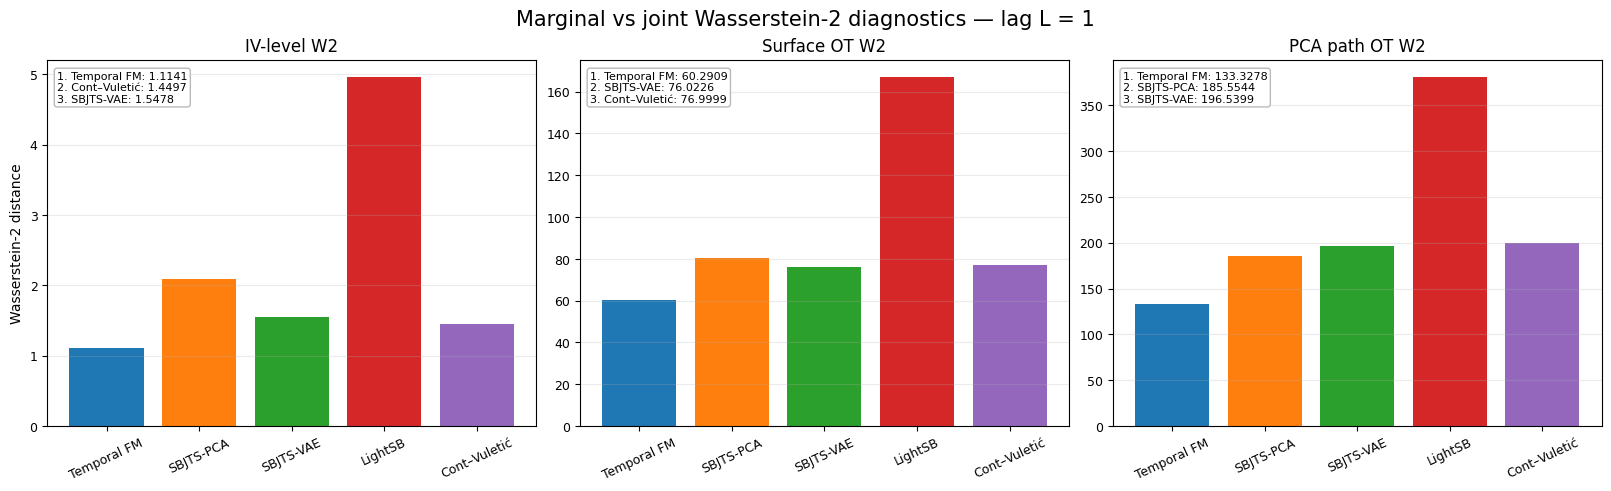

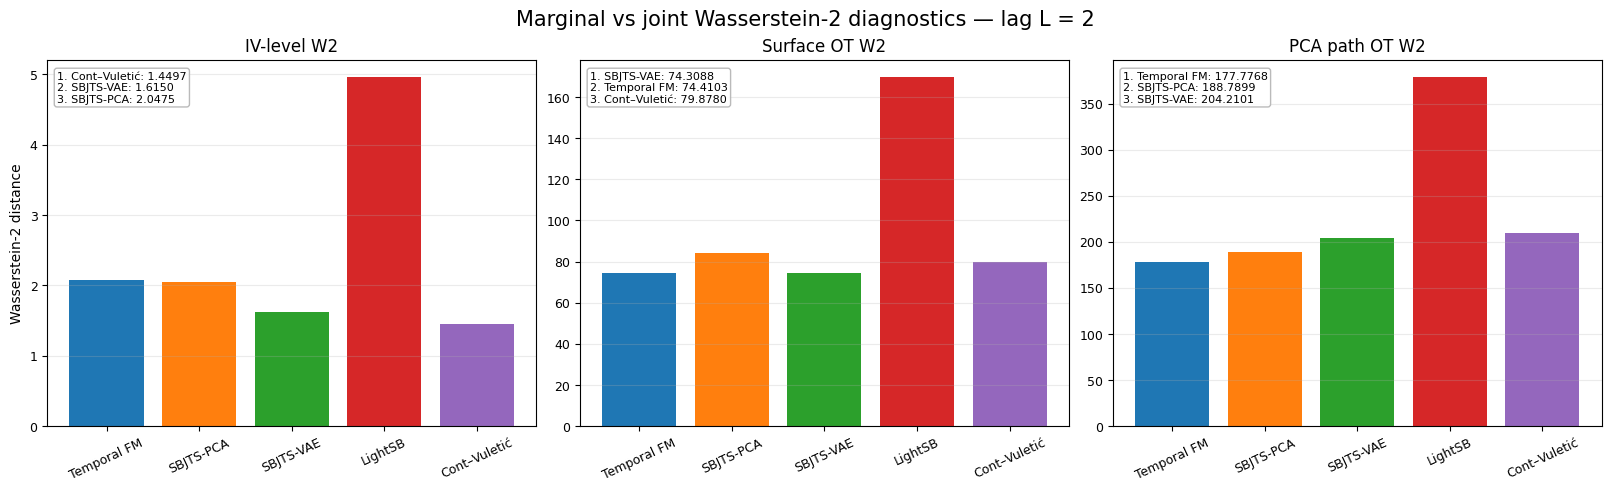

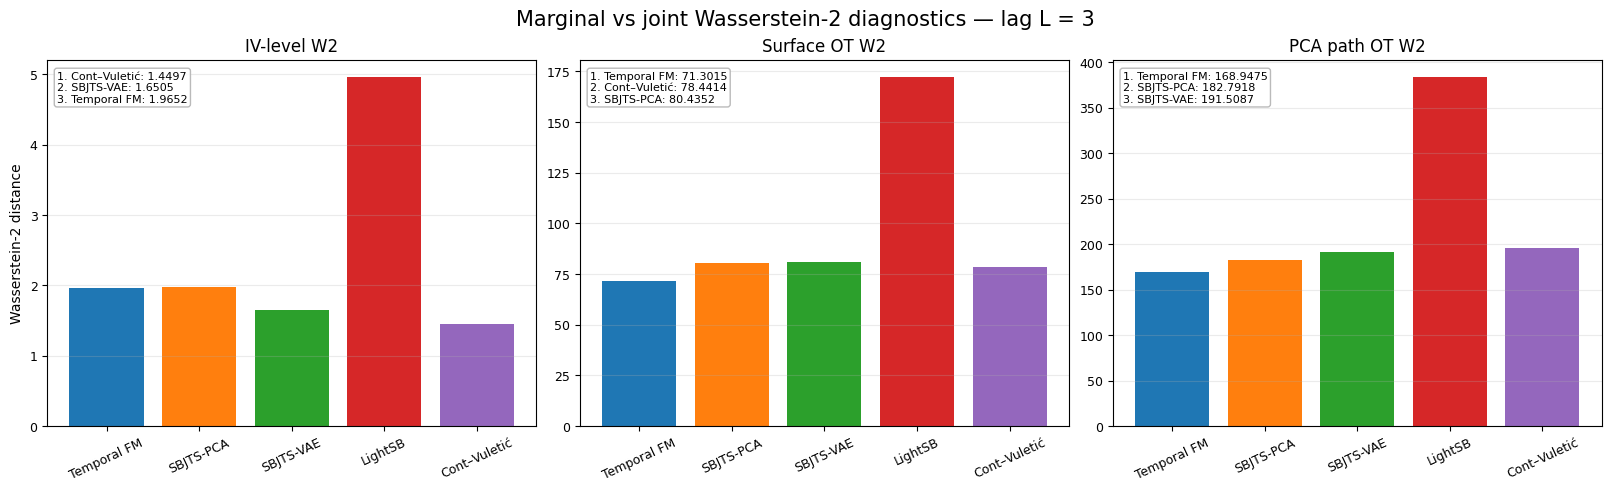

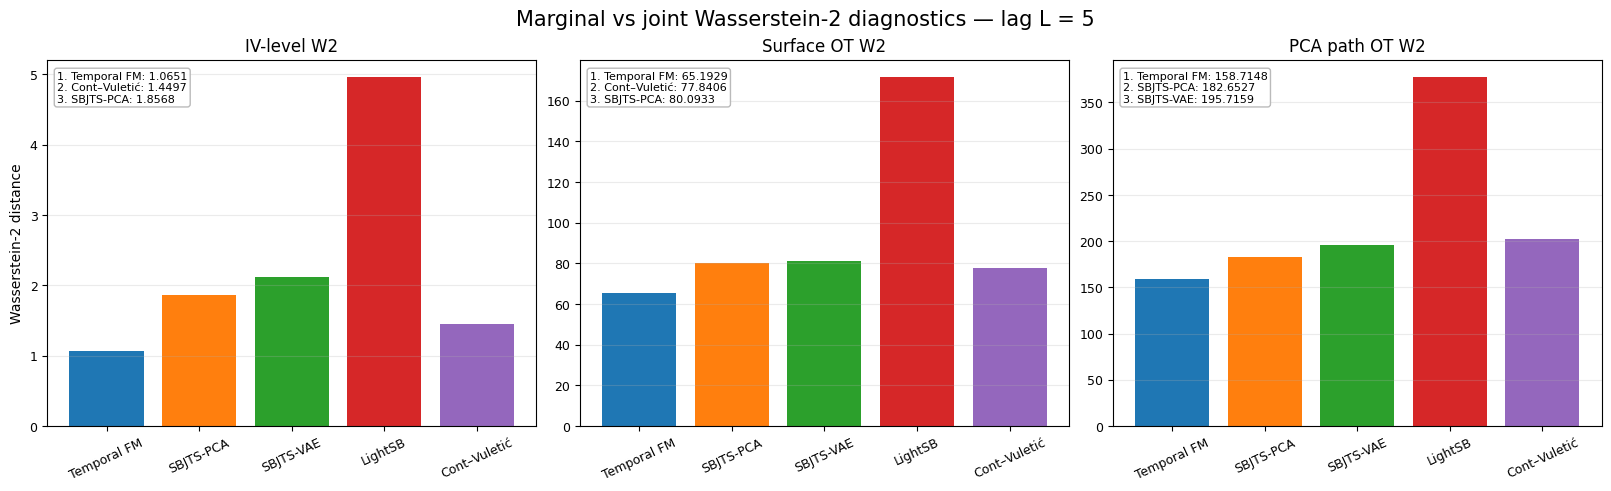

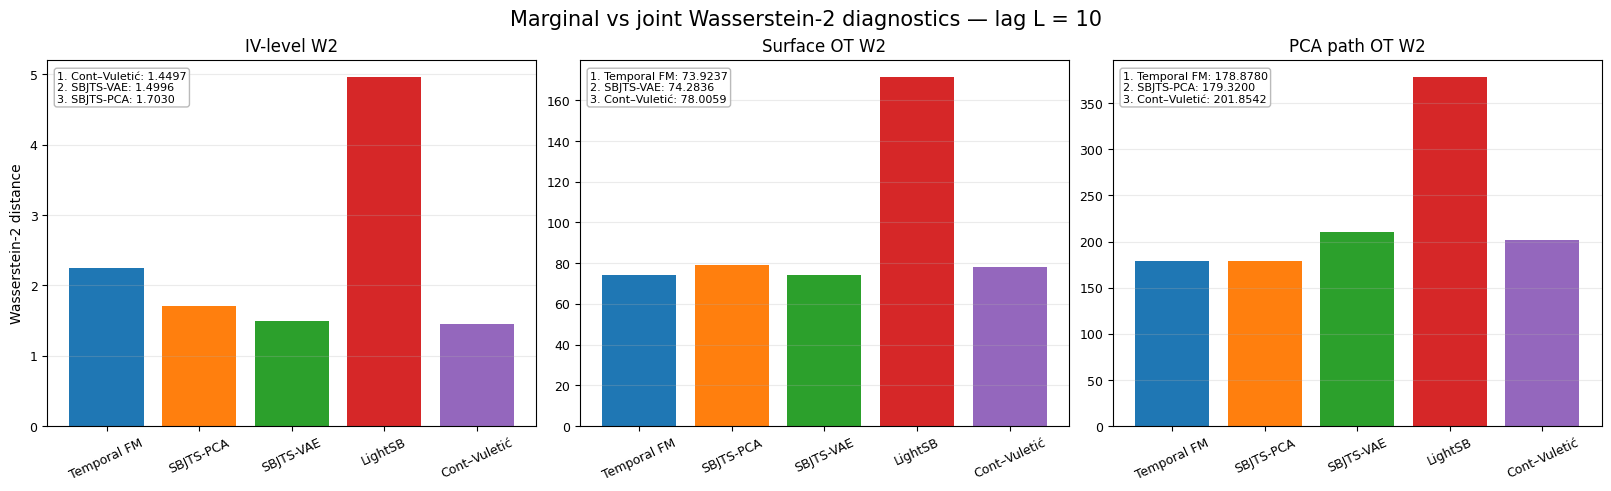

In [13]:

# + join W2 diagnostics

# 1. IV-level W2
#       Existing 1D pooled IV-value W2
#       (renamed from the misleading "Surface W2")

# 2. Surface OT W2
#       True multivariate empirical W2 between complete
#       16 x 32 IV surfaces = 512-dimensional observations

# 3. PCA path OT W2
#       True multivariate empirical W2 between complete
#       5-day paths after projection onto a COMMON PCA basis
#       fitted on REAL surfaces only.

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

PCA_DIM = 8


def _to_pct_joint(x):

    x = np.asarray(
        x,
        dtype=float,
    ).copy()

    if np.nanmedian(x) < 2.0:
        x *= 100.0

    return x


REAL_JOINT = _to_pct_joint(
    REAL_WINDOWS
)


# existing scalar empirical W2 

def _flat_joint(x):

    x = np.asarray(
        x,
        dtype=float,
    ).reshape(-1)

    return x[
        np.isfinite(x)
    ]


def _w2_1d_joint(a, b):
    """
    Exact empirical 1D W2 for possibly unequal sample sizes.

    This is the SAME type of metric currently used in the
    dashboard for pooled IV levels.

    It is NOT multivariate surface OT.
    """

    a = np.sort(
        _flat_joint(a)
    )

    b = np.sort(
        _flat_joint(b)
    )

    if len(a) == 0 or len(b) == 0:
        return np.nan

    na = len(a)
    nb = len(b)

    wa = 1.0 / na
    wb = 1.0 / nb

    i = 0
    j = 0

    rem_a = wa
    rem_b = wb

    dist2 = 0.0
    eps = 1e-15

    while i < na and j < nb:

        mass = min(
            rem_a,
            rem_b,
        )

        dist2 += (
            mass
            * (a[i] - b[j])**2
        )

        rem_a -= mass
        rem_b -= mass

        if rem_a <= eps:
            i += 1
            rem_a = wa

        if rem_b <= eps:
            j += 1
            rem_b = wb

    return float(
        np.sqrt(dist2)
    )



# Multivariate empirical W2

def _finite_rows(x):

    x = np.asarray(
        x,
        dtype=float,
    )

    mask = np.all(
        np.isfinite(x),
        axis=1,
    )

    return x[mask]


def _match_sample_sizes(
    x,
    y,
    seed=12345,
):
    """
    Deterministically subsample the larger empirical measure
    so both measures contain the same number of observations.
    """

    x = _finite_rows(x)
    y = _finite_rows(y)

    n = min(
        len(x),
        len(y),
    )

    if n == 0:
        return x[:0], y[:0]

    rng = np.random.default_rng(
        seed
    )

    if len(x) > n:

        idx = rng.choice(
            len(x),
            size=n,
            replace=False,
        )

        x = x[idx]

    if len(y) > n:

        idx = rng.choice(
            len(y),
            size=n,
            replace=False,
        )

        y = y[idx]

    return x, y


def _multivariate_w2(
    x,
    y,
    seed=12345,
):
    """
    Exact empirical W2 for equal-weight, equal-size samples.

    x : (N, d)
    y : (M, d)

    If N != M, larger sample is deterministically subsampled.

    Returns W2, not W2^2.
    """

    x, y = _match_sample_sizes(
        x,
        y,
        seed=seed,
    )

    if len(x) == 0 or len(y) == 0:
        return np.nan

    if x.shape[1] != y.shape[1]:

        raise ValueError(
            "Feature dimensions differ: "
            f"{x.shape} vs {y.shape}"
        )

    # Squared Euclidean transport cost
    C = cdist(
        x,
        y,
        metric="sqeuclidean",
    )

    row_ind, col_ind = (
        linear_sum_assignment(C)
    )

    w2_squared = np.mean(
        C[
            row_ind,
            col_ind,
        ]
    )

    return float(
        np.sqrt(
            max(w2_squared, 0.0)
        )
    )


# surface representation

def _surface_vectors(paths):
    """
    (n_paths, path_length, tenor, moneyness)
           ->
    (n_paths * path_length, tenor * moneyness)

    Each row remains ONE complete surface.
    """

    x = _to_pct_joint(
        paths
    )

    if x.ndim != 4:

        raise ValueError(
            "Expected paths with shape "
            "(P,H,T,M), got "
            f"{x.shape}"
        )

    return x.reshape(
        -1,
        x.shape[-2] * x.shape[-1],
    )


# common PCA representation:  Fit ONLY on REAL surfaces

real_surface_vectors = _surface_vectors(
    REAL_JOINT
)

PCA_MEAN = np.mean(
    real_surface_vectors,
    axis=0,
    keepdims=True,
)

real_centered = (
    real_surface_vectors
    - PCA_MEAN
)

_, PCA_SINGULAR_VALUES, VT = np.linalg.svd(
    real_centered,
    full_matrices=False,
)

PCA_DIM_USED = min(
    PCA_DIM,
    VT.shape[0],
)

PCA_COMPONENTS = VT[
    :PCA_DIM_USED
].T


# Explained variance diagnostic
explained_variance = (
    PCA_SINGULAR_VALUES**2
)

explained_ratio = (
    explained_variance
    / explained_variance.sum()
)

PCA_EXPLAINED = float(
    explained_ratio[
        :PCA_DIM_USED
    ].sum()
)


print(
    f"Common PCA dimension: {PCA_DIM_USED}"
)

print(
    "Real-surface variance explained: "
    f"{100 * PCA_EXPLAINED:.2f}%"
)


def _project_surfaces_to_common_pca(paths):
    """
    Project every surface onto the SAME PCA basis fitted
    from REAL surfaces.
    """

    vec = _surface_vectors(
        paths
    )

    return (
        vec - PCA_MEAN
    ) @ PCA_COMPONENTS


def _path_vectors_pca(paths):
    """
    Convert complete paths

        (P, H, 16, 32)

    into

        (P, H * PCA_DIM)

    using the common REAL-fitted PCA basis.

    For H=5 and PCA_DIM=8:
        one path = one 40-dimensional observation.
    """

    x = _to_pct_joint(
        paths
    )

    P, H, T, M = x.shape

    surfaces = x.reshape(
        P * H,
        T * M,
    )

    z = (
        surfaces - PCA_MEAN
    ) @ PCA_COMPONENTS

    return z.reshape(
        P,
        H * PCA_DIM_USED,
    )

# real representation

REAL_SURFACE_VEC = _surface_vectors(
    REAL_JOINT
)

REAL_PATH_PCA = _path_vectors_pca(
    REAL_JOINT
)


print(
    "Real surface representation:",
    REAL_SURFACE_VEC.shape,
)

print(
    "Real path PCA representation:",
    REAL_PATH_PCA.shape,
)


joint_w2_results = {}


for L in LAGS:

    models = {}


    for name in [
        "temporal_fm_trigo",
        "sbjts_pca",
        "sbjts_vae",
    ]:

        key = (
            name,
            L,
        )

        if key in lag_results:

            models[name] = _to_pct_joint(
                lag_results[key]
            )


    for name in [
        "lightsb",
        "cont_vuletic",
    ]:

        if name in fixed_results:

            models[name] = _to_pct_joint(
                fixed_results[name]
            )


    ordered_models = [
        name
        for name in MODEL_ORDER
        if name in models
    ]


    results_L = {}


    for model_idx, name in enumerate(
        ordered_models
    ):

        x = models[name]


        iv_level_w2 = _w2_1d_joint(
            REAL_JOINT,
            x,
        )


        model_surface_vec = (
            _surface_vectors(x)
        )

        surface_ot_w2 = (
            _multivariate_w2(
                REAL_SURFACE_VEC,
                model_surface_vec,
                seed=1000
                + 100 * L
                + model_idx,
            )
        )


        model_path_pca = (
            _path_vectors_pca(x)
        )

        path_pca_w2 = (
            _multivariate_w2(
                REAL_PATH_PCA,
                model_path_pca,
                seed=2000
                + 100 * L
                + model_idx,
            )
        )


        results_L[name] = {
            "IV-level W2":
                iv_level_w2,

            "Surface OT W2":
                surface_ot_w2,

            "PCA path OT W2":
                path_pca_w2,
        }


    joint_w2_results[L] = (
        results_L
    )


for L in LAGS:

    if L not in joint_w2_results:
        continue

    results_L = (
        joint_w2_results[L]
    )

    if len(results_L) == 0:
        continue


    print("\n")
    print(
        "=" * 88
    )

    print(
        f"LAG L = {L}"
    )

    print(
        "=" * 88
    )

    print(
        f"{'Model':<20}"
        f"{'IV-level W2':>18}"
        f"{'Surface OT W2':>22}"
        f"{'PCA path OT W2':>22}"
    )

    print(
        "-" * 88
    )


    for name in MODEL_ORDER:

        if name not in results_L:
            continue

        r = results_L[name]

        print(
            f"{DISPLAY[name]:<20}"
            f"{r['IV-level W2']:>18.6f}"
            f"{r['Surface OT W2']:>22.6f}"
            f"{r['PCA path OT W2']:>22.6f}"
        )



    print(
        "\nRankings:"
    )

    for metric in [
        "IV-level W2",
        "Surface OT W2",
        "PCA path OT W2",
    ]:

        ranking = sorted(
            (
                (
                    name,
                    results_L[name][metric],
                )
                for name in results_L
                if np.isfinite(
                    results_L[name][metric]
                )
            ),
            key=lambda z: z[1],
        )

        print(
            f"\n{metric}:"
        )

        for rank, (
            name,
            value,
        ) in enumerate(
            ranking,
            start=1,
        ):

            print(
                f"  {rank}. "
                f"{DISPLAY[name]:<18} "
                f"{value:.6f}"
            )



# IV-level W2 is 1D.
# Surface OT is 512-D Euclidean OT.
# Path OT is PCA-space OT.


for L in LAGS:

    if L not in joint_w2_results:
        continue

    results_L = (
        joint_w2_results[L]
    )

    ordered_models = [
        name
        for name in MODEL_ORDER
        if name in results_L
    ]

    if len(ordered_models) == 0:
        continue


    metrics = [
        "IV-level W2",
        "Surface OT W2",
        "PCA path OT W2",
    ]


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 4.8),
        constrained_layout=True,
    )


    fig.suptitle(
        (
            "Marginal vs joint Wasserstein-2 diagnostics "
            f"— lag L = {L}"
        ),
        fontsize=15,
    )


    for ax, metric in zip(
        axes,
        metrics,
    ):

        vals = [
            results_L[name][metric]
            for name in ordered_models
        ]

        ax.bar(
            [
                DISPLAY[name]
                for name in ordered_models
            ],
            vals,
            color=[
                COLORS[name]
                for name in ordered_models
            ],
        )


        # Best three models

        ranking = sorted(
            zip(
                ordered_models,
                vals,
            ),
            key=lambda z: z[1],
        )

        text = "\n".join(
            [
                (
                    f"{rank}. "
                    f"{DISPLAY[name]}: "
                    f"{value:.4f}"
                )
                for rank, (
                    name,
                    value,
                )
                in enumerate(
                    ranking[:3],
                    start=1,
                )
            ]
        )


        ax.text(
            0.02,
            0.97,
            text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.7",
                alpha=0.90,
            ),
        )


        ax.set_title(
            metric
        )

        ax.tick_params(
            axis="x",
            rotation=25,
        )

        ax.grid(
            axis="y",
            alpha=0.25,
        )


    axes[0].set_ylabel(
        "Wasserstein-2 distance"
    )

    plt.show()